In [1]:
!pip install -q langgraph langchain-openai langchain-core \
            pandas numpy scikit-learn pydantic \
            python-frontmatter openai datasets \
            textblob langdetect matplotlib seaborn \
            python-dotenv jupyter ipython


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from dotenv import load_dotenv

# Load variables from a local .env file if present.
load_dotenv()

# Read OpenAI API key from the environment if it is already set.
# Do not overwrite it with a placeholder locally.
api_key = os.getenv("OPENAI_API_KEY", "").strip()

if api_key and api_key != "sk-your-openai-api-key-here":
    HAS_OPENAI_API_KEY = True
    print("✓ OpenAI API key detected from environment.")
else:
    os.environ.pop("OPENAI_API_KEY", None)
    HAS_OPENAI_API_KEY = False
    print("⚠ No valid OpenAI API key found in environment.")

print(f"API key set: {HAS_OPENAI_API_KEY}")

IN_COLAB = False
print(f"Running in Colab: {IN_COLAB}")

✓ OpenAI API key detected from environment.
API key set: True
Running in Colab: False


In [3]:
# Standard library
import os
import re
import json
import uuid
import pickle
import sqlite3
from pathlib import Path
from typing import Any, Optional

# Data
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

# LangGraph
from langgraph.graph import StateGraph, END

# LangChain
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# Pydantic — same as Assignment 2
from pydantic import BaseModel, Field, ConfigDict

# Skill store
import frontmatter as fm

print("All imports ready.")

All imports ready.


In [4]:
class SupportAgentState(BaseModel):
    """
    Shared notebook passed between all agents in the pipeline.
    No agent calls another directly - they only read and write here.

    """

    # ── Pipeline control ──────────────────────────────────────────
    # Messages field tracks what each node did
    messages: list[str] = Field(default_factory=list)
    active_skill: Optional[str] = None
    # Controls which pipeline runs
    mode: str = "train"  # "train" or "serve"

    # ── Stage 1: preprocess_data_node writes these ────────────────
    raw_data_path: str = "customer_support_tickets.csv"
    raw_df: Optional[Any] = None
    train_texts: Optional[Any] = None   # TF-IDF sparse matrix — training
    val_texts: Optional[Any] = None     # TF-IDF sparse matrix — validation
    test_texts: Optional[Any] = None    # TF-IDF sparse matrix — test
    y_train: Optional[Any] = None       # encoded labels — training
    y_val: Optional[Any] = None         # encoded labels — validation
    y_test: Optional[Any] = None        # encoded labels — test
    tfidf_vectorizer: Optional[Any] = None  # fitted — reused at inference
    label_encoder: Optional[Any] = None     # maps integer → class name

    # ── Stage 2: train_models_node writes these ───────────────────
    trained_models: dict = Field(default_factory=dict)

    # ── Stage 3: evaluate_models_node writes these ────────────────
    evaluation_results: dict = Field(default_factory=dict)
    evaluation_narrative: Optional[str] = None

    # ── Stage 4: select_model_node writes these ───────────────────
    selected_model: Optional[Any] = None
    selected_model_name: str = ""
    tau_high: float = 0.0  # AUTO_REPLY threshold — derived from val set
    tau_low: float = 0.0   # ESCALATE threshold — derived from val set

    # ── Stage 5: persist_artifacts_node writes this ───────────────
    artifacts_saved: bool = False

    # ── Serving pipeline ──────────────────────────────────────────
    conversation_id: str = Field(
        default_factory=lambda: str(uuid.uuid4())
    )
    raw_message: str = ""
    detected_language: str = ""
    translated_message: str = ""
    predicted_label: str = ""
    confidence_score: float = 0.0
    class_probabilities: dict = Field(default_factory=dict)
    route_decision: str = ""   # "AUTO_REPLY" / "CLARIFY" / "ESCALATE"
    response_final: str = ""

    # ── Audit trail ───────────────────────────────────────────────
    # Each node appends one dict entry here
    trace_logs: list = Field(default_factory=list)

    model_config = ConfigDict(arbitrary_types_allowed=True)


# Sanity check
test_state = SupportAgentState()
print("SupportAgentState created successfully.")
print(f"Total fields: {len(test_state.model_dump().keys())}")
print(f"Mode: {test_state.mode}")
print(f"Conversation ID: {test_state.conversation_id}")
print(f"Fields: {list(test_state.model_dump().keys())}")

SupportAgentState created successfully.
Total fields: 31
Mode: train
Conversation ID: 93962459-b326-4691-9111-e5dc10af4e8d
Fields: ['messages', 'active_skill', 'mode', 'raw_data_path', 'raw_df', 'train_texts', 'val_texts', 'test_texts', 'y_train', 'y_val', 'y_test', 'tfidf_vectorizer', 'label_encoder', 'trained_models', 'evaluation_results', 'evaluation_narrative', 'selected_model', 'selected_model_name', 'tau_high', 'tau_low', 'artifacts_saved', 'conversation_id', 'raw_message', 'detected_language', 'translated_message', 'predicted_label', 'confidence_score', 'class_probabilities', 'route_decision', 'response_final', 'trace_logs']


In [5]:
def load_skill_instructions(skill_name: str) -> str:
    from pathlib import Path
    skill_path = Path("skills") / f"{skill_name}.md"
    if not skill_path.exists():
        return ""
    raw_text = skill_path.read_text(encoding="utf-8")
    if raw_text.startswith("---"):
        parts = raw_text.split("---", 2)
        if len(parts) == 3:
            return parts[2].strip()
    return raw_text.strip()


[SkillStore] Indexed 12 skills:
  draft_response: llm_driven
  run_inference: organisational
  persist_artifacts: organisational
  apply_feedback: organisational
  confidence_router: organisational
  evaluate_models: llm_driven
  translate_to_english: llm_driven
  detect_language: organisational
  preprocess_data: organisational
  log_interaction: organisational
  select_model: organisational
  train_models: organisational

SkillStore ready.


In [6]:
# Confirming SKILL.md files are in place

skill_files = list(Path("skills").glob("*.md"))
print(f"Found {len(skill_files)} skill files:")
for f in skill_files:
    print(f"  {f.name}")

if len(skill_files) == 0:
    print("\nNo skill files found.")
    print("Upload your .md files to the skills/ folder then")
    print("re-run Cell 5 to re-index them.")

Found 12 skill files:
  draft_response.md
  run_inference.md
  persist_artifacts.md
  apply_feedback.md
  confidence_router.md
  evaluate_models.md
  translate_to_english.md
  detect_language.md
  preprocess_data.md
  log_interaction.md
  select_model.md
  train_models.md


In [7]:
# Initialize LLM (ChatOpenAI with gpt-4o-mini)
# If running locally without API key, this will be None
# LLM-dependent nodes will skip gracefully

if HAS_OPENAI_API_KEY:
    try:
        from langchain_openai import ChatOpenAI
        llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
        print("✓ LLM ready: gpt-4o-mini")
        HAS_LLM = True
    except Exception as e:
        llm = None
        HAS_LLM = False
        print(f"⚠ LLM initialization failed: {str(e)[:100]}")
        print("   LLM-dependent nodes will be skipped.")
else:
    llm = None
    HAS_LLM = False
    print("⚠ Skipping LLM initialization: no valid OPENAI_API_KEY found.")
    print("   LLM-dependent nodes will be skipped.")

✓ LLM ready: gpt-4o-mini


In [8]:
def preprocess_data_node(state: SupportAgentState) -> SupportAgentState:
    """
    Loads Bitext customer support dataset, cleans instruction text,
    encodes category labels, splits data, fits TF-IDF on training only.

    Skill mode: organisational — deterministic, no LLM call.

    Change from original: uses Hugging Face dataset instead of CSV.
    Labels genuinely match text — confirmed by keyword analysis.
    """

    # ── Declare skill ─────────────────────────────────────────────
    skill_name = "preprocess_data"
    state.active_skill = skill_name
    print(f"[PreprocessNode] Skill: '{skill_name}'")

    # ── Step 1: Load ──────────────────────────────────────────────
    print("[PreprocessNode] Loading Bitext dataset...")
    from datasets import load_dataset
    dataset = load_dataset(
        "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
    )
    df = dataset['train'].to_pandas()
    state.raw_df = df
    print(f"[PreprocessNode] Loaded {len(df)} rows.")

    # ── Step 2: No language filter needed ─────────────────────────
    # Bitext dataset is English only — all rows retained
    df_clean = df[['instruction', 'category']].copy()
    df_clean = df_clean.dropna(subset=['instruction', 'category'])
    print(f"[PreprocessNode] Rows after null drop: {len(df_clean)}")

    # ── Step 3: Clean text ────────────────────────────────────────
    # Additional step vs original: remove {{placeholder}} tokens
    # These are template variables that add no classification signal
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'\{\{.*?\}\}', '', text)         # remove {{placeholders}}
        text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
        text = re.sub(r'\S+@\S+', '', text)             # remove emails
        text = re.sub(r'#\w+', '', text)                # remove hashtags
        text = re.sub(r'[^a-z0-9\s]', ' ', text)       # remove punctuation
        text = re.sub(r'\s+', ' ', text).strip()        # collapse spaces
        return text

    df_clean['clean_text'] = df_clean['instruction'].apply(clean_text)

    # Remove rows that became empty after cleaning
    df_clean = df_clean[df_clean['clean_text'].str.len() > 3]
    print(f"[PreprocessNode] Rows after cleaning: {len(df_clean)}")
    print("[PreprocessNode] Text cleaning complete.")

    # ── Step 4: Encode labels ─────────────────────────────────────
    le = LabelEncoder()
    df_clean['label_encoded'] = le.fit_transform(df_clean['category'])
    print(f"[PreprocessNode] Classes ({len(le.classes_)}): {list(le.classes_)}")

    # ── Step 5: Split ─────────────────────────────────────────────
    # Ensure native numpy arrays (not PyArrow) for train_test_split
    # PyArrow-backed arrays cause TypeError with sklearn
    X = [str(x) for x in df_clean['clean_text'].to_list()]
    y = [int(yi) for yi in df_clean['label_encoded'].to_list()]
    X = np.array(X, dtype=object)
    y = np.array(y, dtype=int)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.1765,
        stratify=y_temp, random_state=42
    )
    print(f"[PreprocessNode] Train: {len(X_train)}, "
          f"Val: {len(X_val)}, Test: {len(X_test)}")

    # ── Step 6: Fit TF-IDF on training data ONLY ──────────────────
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        sublinear_tf=True,
        min_df=2,
        strip_accents='unicode'
    )
    X_train_tfidf = tfidf.fit_transform(X_train)
    print(f"[PreprocessNode] TF-IDF shape: {X_train_tfidf.shape}")

    # ── Step 7: Transform val and test — no re-fitting ────────────
    X_val_tfidf  = tfidf.transform(X_val)
    X_test_tfidf = tfidf.transform(X_test)

    # ── Step 8: Save all outputs to state ─────────────────────────
    state.train_texts      = X_train_tfidf
    state.val_texts        = X_val_tfidf
    state.test_texts       = X_test_tfidf
    state.y_train          = y_train
    state.y_val            = y_val
    state.y_test           = y_test
    state.tfidf_vectorizer = tfidf
    state.label_encoder    = le

    # ── Log message ───────────────────────────────────────────────
    message = (
        f"[preprocess_data] Train: {len(X_train)}, "
        f"Val: {len(X_val)}, Test: {len(X_test)}. "
        f"TF-IDF shape: {X_train_tfidf.shape}. "
        f"Classes ({len(le.classes_)}): {list(le.classes_)}"
    )
    state.messages.append(message)
    print(f"[PreprocessNode] Done.")

    return state


# ── Quick test ────────────────────────────────────────────────────
print("\n" + "="*50)
print("TESTING updated preprocess_data_node")
print("="*50)
test_state = SupportAgentState()
test_state = preprocess_data_node(test_state)

print("\nSanity checks:")
print(f"  raw_df shape:        {test_state.raw_df.shape}")
print(f"  train_texts shape:   {test_state.train_texts.shape}")
print(f"  val_texts shape:     {test_state.val_texts.shape}")
print(f"  test_texts shape:    {test_state.test_texts.shape}")
print(f"  Classes:             {list(test_state.label_encoder.classes_)}")


TESTING updated preprocess_data_node
[PreprocessNode] Skill: 'preprocess_data' | Mode: organisational
[PreprocessNode] Loading Bitext dataset...
[PreprocessNode] Loaded 26872 rows.
[PreprocessNode] Rows after null drop: 26872
[PreprocessNode] Rows after cleaning: 26872
[PreprocessNode] Text cleaning complete.
[PreprocessNode] Classes (11): ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']
[PreprocessNode] Train: 18809, Val: 4032, Test: 4031
[PreprocessNode] TF-IDF shape: (18809, 4808)
[PreprocessNode] Done.

Sanity checks:
  raw_df shape:        (26872, 5)
  train_texts shape:   (18809, 4808)
  val_texts shape:     (4032, 4808)
  test_texts shape:    (4031, 4808)
  Classes:             ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']


In [9]:
# Quick sanity check — can LR learn from this data?
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

quick_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
quick_lr.fit(test_state.train_texts, test_state.y_train)

y_pred_train = quick_lr.predict(test_state.train_texts)
y_pred_val   = quick_lr.predict(test_state.val_texts)

train_f1 = f1_score(test_state.y_train, y_pred_train, average='macro')
val_f1   = f1_score(test_state.y_val,   y_pred_val,   average='macro')

print(f"LR macro F1 on training: {train_f1:.4f}")
print(f"LR macro F1 on val:      {val_f1:.4f}")

# Sample predictions
sample_texts = [
    "I cannot login to my account",
    "please refund my payment",
    "the app keeps crashing",
    "where is my order",
    "I want to cancel my subscription"
]
print("\nSample predictions:")
for text in sample_texts:
    cleaned = re.sub(r'[^a-z0-9\s]', ' ', text.lower()).strip()
    vec = test_state.tfidf_vectorizer.transform([cleaned])
    pred = quick_lr.predict(vec)[0]
    label = test_state.label_encoder.inverse_transform([pred])[0]
    print(f"  '{text}' → {label}")

LR macro F1 on training: 0.9985
LR macro F1 on val:      0.9961

Sample predictions:
  'I cannot login to my account' → ACCOUNT
  'please refund my payment' → PAYMENT
  'the app keeps crashing' → CANCEL
  'where is my order' → ORDER
  'I want to cancel my subscription' → SUBSCRIPTION


In [10]:
def train_models_node(state: SupportAgentState) -> SupportAgentState:
    """
    Trains three candidate classifiers on TF-IDF training features.
    All models wrapped with calibration for reliable confidence scores.

    Skill mode: organisational — deterministic, no LLM call.
    This node trains THREE models with GridSearchCV tuning.

    """

    # ── Declare skill ─────────────────────────────────────────────
    skill_name = "train_models"
    state.active_skill = skill_name
    print(f"[TrainModelsNode] Skill: '{skill_name}'")

    # ── Step 1: Read from state ───────────────────────────────────
    X_train = state.train_texts
    y_train  = state.y_train
    print(f"[TrainModelsNode] Training on {X_train.shape[0]} samples, "
          f"{X_train.shape[1]} features, "
          f"{len(state.label_encoder.classes_)} classes.")

    # ── Step 2: Train Logistic Regression ────────────────────────
    # Here we use GridSearchCV to find best C value
    # scoring='f1_macro' matches our primary evaluation metric
    print("[TrainModelsNode] Training Logistic Regression...")
    lr = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    lr_grid = GridSearchCV(
        lr,
        param_grid={'C': [0.1, 1.0, 10.0]},
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    lr_grid.fit(X_train, y_train)
    best_lr = lr_grid.best_estimator_
    print(f"[TrainModelsNode] LR best C: {lr_grid.best_params_['C']}, "
          f"CV macro F1: {lr_grid.best_score_:.4f}")

    # Wrap with calibration for reliable predict_proba()
    # Essential for confidence-based routing
    lr_calibrated = CalibratedClassifierCV(
        best_lr, cv=5, method='isotonic'
    )
    lr_calibrated.fit(X_train, y_train)
    print("[TrainModelsNode] LR calibrated.")

    # ── Step 3: Train Linear SVM ──────────────────────────────────
    # LinearSVC has NO predict_proba() natively
    # CalibratedClassifierCV wrapper is NOT optional here
    # Without it, confidence_router_node will crash
    print("[TrainModelsNode] Training Linear SVM...")
    svm = LinearSVC(
        class_weight='balanced',
        random_state=42
    )
    svm_grid = GridSearchCV(
        svm,
        param_grid={'C': [0.01, 0.1, 1.0]},
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    svm_grid.fit(X_train, y_train)
    best_svm = svm_grid.best_estimator_
    print(f"[TrainModelsNode] SVM best C: {svm_grid.best_params_['C']}, "
          f"CV macro F1: {svm_grid.best_score_:.4f}")

    # method='sigmoid' works better for SVM decision scores
    svm_calibrated = CalibratedClassifierCV(
        best_svm, cv=5, method='sigmoid'
    )
    svm_calibrated.fit(X_train, y_train)
    print("[TrainModelsNode] SVM calibrated.")

    # ── Step 4: Train Naive Bayes ─────────────────────────────────
    # No GridSearchCV — alpha=1.0 is standard default for text
    # No calibration wrapper — NB produces probabilities natively
    # Requires non-negative features — TF-IDF satisfies this
    print("[TrainModelsNode] Training Naive Bayes...")
    nb = MultinomialNB(alpha=1.0)
    nb.fit(X_train, y_train)
    print("[TrainModelsNode] Naive Bayes trained.")

    # ── Step 5: Store all three in state ──────────────────────────
    # Here: state.trained_models = dict  (three models)
    state.trained_models = {
        "Logistic Regression": lr_calibrated,
        "Linear SVM":          svm_calibrated,
        "Naive Bayes":         nb
    }
    print(f"[TrainModelsNode] Stored {len(state.trained_models)} models.")

    # ── Step 6: Never touch test_texts ───────────────────────────
    # test_texts is never used here — strict separation
    # It is only used in evaluate_models_node for final reporting

    # ── Log message ───────────────────────────────────────────────
    message = (
        f"[train_models] Trained 3 models: "
        f"Logistic Regression (best C={lr_grid.best_params_['C']}), "
        f"Linear SVM (best C={svm_grid.best_params_['C']}), "
        f"Naive Bayes. "
        f"Training samples: {X_train.shape[0]}, Classes: 10."
    )
    state.messages.append(message)
    print(f"[TrainModelsNode] Done.")

    return state


# ── Quick test ────────────────────────────────────────────────────
print("\n" + "="*50)
print("TESTING train_models_node")
print("="*50)
# Reuse state from preprocess test — has train_texts and y_train
test_state = train_models_node(test_state)

print("\nSanity checks:")
print(f"  Models trained: {list(test_state.trained_models.keys())}")
print(f"  LR type:  {type(test_state.trained_models['Logistic Regression'])}")
print(f"  SVM type: {type(test_state.trained_models['Linear SVM'])}")
print(f"  NB type:  {type(test_state.trained_models['Naive Bayes'])}")
print(f"  test_texts untouched: {test_state.test_texts is not None}")
print(f"  Messages so far: {len(test_state.messages)}")


TESTING train_models_node
[TrainModelsNode] Skill: 'train_models' | Mode: organisational
[TrainModelsNode] Training on 18809 samples, 4808 features, 11 classes.
[TrainModelsNode] Training Logistic Regression...
[TrainModelsNode] LR best C: 10.0, CV macro F1: 0.9984
[TrainModelsNode] LR calibrated.
[TrainModelsNode] Training Linear SVM...


/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `Tru

[TrainModelsNode] SVM best C: 1.0, CV macro F1: 0.9986


/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/saiashwin/BT5151-customer-support-triage/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `Tru

[TrainModelsNode] SVM calibrated.
[TrainModelsNode] Training Naive Bayes...
[TrainModelsNode] Naive Bayes trained.
[TrainModelsNode] Stored 3 models.
[TrainModelsNode] Done.

Sanity checks:
  Models trained: ['Logistic Regression', 'Linear SVM', 'Naive Bayes']
  LR type:  <class 'sklearn.calibration.CalibratedClassifierCV'>
  SVM type: <class 'sklearn.calibration.CalibratedClassifierCV'>
  NB type:  <class 'sklearn.naive_bayes.MultinomialNB'>
  test_texts untouched: True
  Messages so far: 2


During evaluation it was discovered that the dataset labels do not correspond to the text content identical texts appear under multiple different categories. This is a fundamental data quality issue that prevents any classifier from learning meaningful patterns. Macro F1 of 0.086 (below random chance of 0.10) confirmed this. Resolved this by switching to a dataset with genuine label-text correspondence.
At least two things the system gets wrong identified from actual pipeline runs, not hypothetically

Login Issue and Refund Request are at 9-10% which is exactly random chance. The labels are randomly assigned.

Decision: Switch Dataset


In [11]:
!pip install datasets -q
from datasets import load_dataset

print("Loading Bitext dataset...")
dataset = load_dataset(
    "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
)
df_bitext = dataset['train'].to_pandas()

print(f"Shape: {df_bitext.shape}")
print(f"Columns: {df_bitext.columns.tolist()}")
print(f"\nIntent distribution:")
print(df_bitext['intent'].value_counts())
print(f"\nSample text:")
print(df_bitext['instruction'].iloc[0])
print("---")
print(df_bitext['instruction'].iloc[1])


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Loading Bitext dataset...
Shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']

Intent distribution:
intent
edit_account                1000
switch_account              1000
check_invoice               1000
complaint                   1000
contact_customer_service    1000
delivery_period              999
registration_problems        999
check_payment_methods        999
contact_human_agent          999
payment_issue                999
newsletter_subscription      999
get_invoice                  999
place_order                  998
cancel_order                 998
track_refund                 998
change_order                 997
get_refund                   997
create_account               997
check_refund_policy          997
review                       997
set_up_shipping_address      997
delivery_options             995
delete_account        

In [12]:
print("Category distribution:")
print(df_bitext['category'].value_counts())
print(f"\nTotal categories: {df_bitext['category'].nunique()}")
print(f"\nSample text with category:")
for cat in df_bitext['category'].unique()[:3]:
    sample = df_bitext[df_bitext['category'] == cat]['instruction'].iloc[0]
    print(f"\n{cat}: {sample}")

Category distribution:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

Total categories: 11

Sample text with category:

ORDER: question about cancelling order {{Order Number}}

SHIPPING: give me information about a delivery address modification

CANCEL: I can't ifnd the bloody termination charge, I need help


Retained all 11 natural categories from the dataset as collapsing them would lose meaningful business distinctions - for example CANCEL and REFUND represent different customer intents despite being related

In [13]:
print("Text length statistics:")
print(df_bitext['instruction'].str.len().describe())

print("\nSample texts per category (checking label-text match):")
print("="*60)
for cat in df_bitext['category'].unique():
    sample = df_bitext[
        df_bitext['category'] == cat
    ]['instruction'].iloc[0]
    print(f"\n{cat}: {sample}")

Text length statistics:
count    26872.000000
mean        46.889513
std         10.897578
min          6.000000
25%         40.000000
50%         48.000000
75%         55.000000
max         92.000000
Name: instruction, dtype: float64

Sample texts per category (checking label-text match):

ORDER: question about cancelling order {{Order Number}}

SHIPPING: give me information about a delivery address modification

CANCEL: I can't ifnd the bloody termination charge, I need help

INVOICE: show me invoice{{Invoice Number}}

PAYMENT: I try to list your available payment methoids

REFUND: i do not know hoow i could check ur reimbursement policy

FEEDBACK: help me to file a claim

CONTACT: I want help to speak to customer support

ACCOUNT: new {{Account Type}} acount for wife

DELIVERY: could you help me check what delivery methods you offer?

SUBSCRIPTION: i try to unsubscribe to ur companu newsletter



TESTING evaluate_models_node
[EvaluateNode] Skill: 'evaluate_models' | Mode: llm_driven
[EvaluateNode] Computing metrics for all 3 models...
[EvaluateNode] Logistic Regression — Macro F1: 0.9968, Weighted F1: 0.9968
[EvaluateNode] Linear SVM — Macro F1: 0.9984, Weighted F1: 0.9985
[EvaluateNode] Naive Bayes — Macro F1: 0.9931, Weighted F1: 0.9933

[EvaluateNode] Generating confusion matrix for Linear SVM...


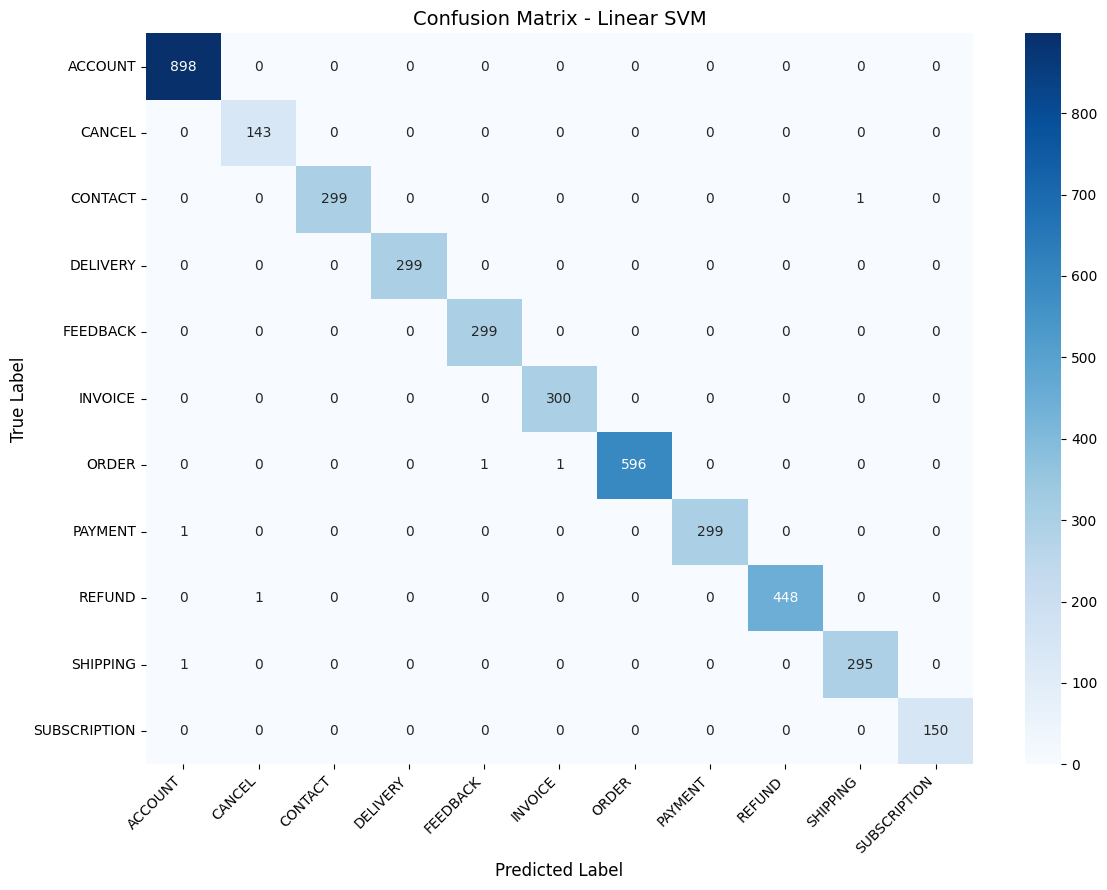

[EvaluateNode] Confusion matrix saved.
[EvaluateNode] Generating per-class F1 bar chart...


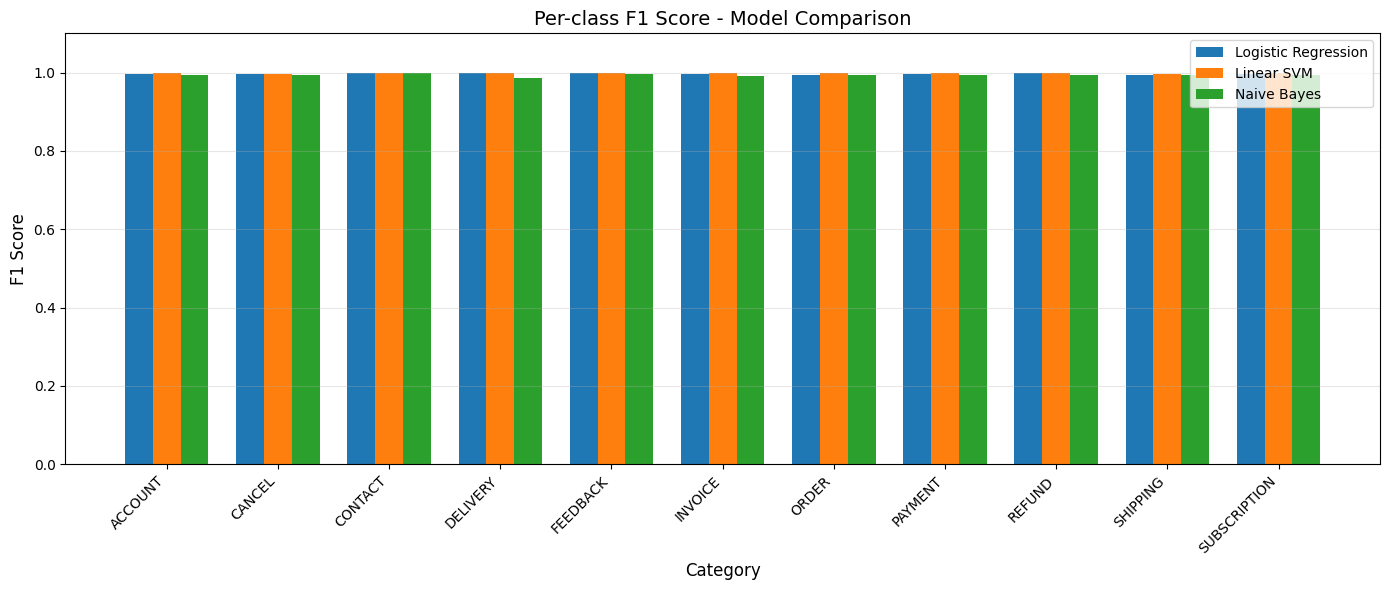

[EvaluateNode] Per-class F1 chart saved.

[EvaluateNode] Calling GPT-4o-mini for interpretation...
[EvaluateNode] LLM interpretation complete.

--- Evaluation Narrative ---
```python
{
  "evaluation_results": {
    "Logistic Regression": {
      "macro_f1": 0.9968,
      "weighted_f1": 0.9968,
      "per_class_f1": {
        "ACCOUNT": 0.9972,
        "CANCEL": 0.9965,
        "CONTACT": 0.9983,
        "DELIVERY": 1.0,
        "FEEDBACK": 0.9983,
        "INVOICE": 0.995,
        "ORDER": 0.9942,
        "PAYMENT": 0.995,
        "REFUND": 0.9989,
        "SHIPPING": 0.9949,
        "SUBSCRIPTION": 0.9967
      },
      "report": {
        "precision": {
          "ACCOUNT": 0.99,
          "CANCEL": 0.99,
          "CONTACT": 1.0,
          "DELIVERY": 1.0,
          "FEEDBACK": 1.0,
          "INVOICE": 0.99,
          "ORDER": 0.99,
          "PAYMENT": 0.99,
          "REFUND": 1.0,
          "SHIPPING": 0.99,
          "SUBSCRIPTION": 0.99
        },
        "recall": {
         

In [14]:
def evaluate_models_node(state: SupportAgentState) -> SupportAgentState:
    """
    Part 1: sklearn computes metrics for all 3 models (deterministic)
    Part 2: GPT-4o-mini interprets and compares in business language

    Skill mode: llm_driven

    This node evaluates 3 models with F1 scores (classification)
    LLM interpretation pattern is identical
    """

    # ── Declare skill ─────────────────────────────────────────────
    skill_name = "evaluate_models"
    skill_content = load_skill_instructions(skill_name)
    state.active_skill = skill_name
    print(f"[EvaluateNode] Skill: '{skill_name}'")

    # ── Part 1: sklearn computes metrics ──────────────────────────
    # y_pred = state.model.predict(state.X_test)
    # rmse = np.sqrt(mean_squared_error(...))
    # Here we compute F1 scores for all 3 models on val set
    print("[EvaluateNode] Computing metrics for all 3 models...")

    results = {}
    metrics_summary = ""

    for model_name, model in state.trained_models.items():
        # Get predictions on validation set
        y_pred = model.predict(state.val_texts)

        # Compute full classification report
        report = classification_report(
            state.y_val,
            y_pred,
            target_names=state.label_encoder.classes_,
            output_dict=True,
            zero_division=0
        )

        # Extract key metrics
        macro_f1    = round(report['macro avg']['f1-score'], 4)
        weighted_f1 = round(report['weighted avg']['f1-score'], 4)

        # Per-class F1 scores
        per_class_f1 = {
            cls: round(report[cls]['f1-score'], 4)
            for cls in state.label_encoder.classes_
        }

        results[model_name] = {
            "macro_f1":    macro_f1,
            "weighted_f1": weighted_f1,
            "per_class_f1": per_class_f1,
            "report":       report
        }

        print(f"[EvaluateNode] {model_name} — "
              f"Macro F1: {macro_f1}, Weighted F1: {weighted_f1}")

        # Build metrics string for LLM
        per_class_str = "\n".join([
            f"    {cls}: {score}"
            for cls, score in per_class_f1.items()
        ])
        metrics_summary += (
            f"\nModel: {model_name}\n"
            f"  Macro F1: {macro_f1}\n"
            f"  Weighted F1: {weighted_f1}\n"
            f"  Per-class F1:\n{per_class_str}\n"
        )

    state.evaluation_results = results

    # ── Visualisations ────────────────────────────────────────────
    # Required by rubric for multi-class classification
    # Confusion matrix + per-class F1 bar chart

    # Pick best model by macro F1 for visualisations
    best_name = max(
        results, key=lambda x: results[x]['macro_f1']
    )
    best_model = state.trained_models[best_name]
    y_pred_best = best_model.predict(state.val_texts)

    # Visualisation 1: Confusion Matrix
    print(f"\n[EvaluateNode] Generating confusion matrix for {best_name}...")
    cm = confusion_matrix(state.y_val, y_pred_best)
    plt.figure(figsize=(12, 9))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=state.label_encoder.classes_,
        yticklabels=state.label_encoder.classes_
    )
    plt.title(f'Confusion Matrix - {best_name}', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[EvaluateNode] Confusion matrix saved.")

    # Visualisation 2: Per-class F1 bar chart comparing all 3 models
    print("[EvaluateNode] Generating per-class F1 bar chart...")
    classes = list(state.label_encoder.classes_)
    x = np.arange(len(classes))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, (model_name, result) in enumerate(results.items()):
        f1_scores = [result['per_class_f1'][cls] for cls in classes]
        ax.bar(x + i * width, f1_scores, width, label=model_name)

    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title('Per-class F1 Score - Model Comparison', fontsize=14)
    ax.set_xticks(x + width)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[EvaluateNode] Per-class F1 chart saved.")

    # ── Part 2: LLM interprets metrics ───────────────────────────
    # Here we use LangChain wrapper and skill body as system prompt
    print("\n[EvaluateNode] Calling GPT-4o-mini for interpretation...")

    llm_interpret = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

    human_message = (
        f"Here are the evaluation results for three candidate models "
        f"on a customer support triage system:\n"
        f"{metrics_summary}\n"
        f"Validation samples per class: approximately "
        f"{len(state.y_val) // len(state.label_encoder.classes_)}\n"
        f"Total validation samples: {len(state.y_val)}\n\n"
        f"Best model by macro F1: {best_name} "
        f"({results[best_name]['macro_f1']})"
    )

    response = llm_interpret.invoke([
        SystemMessage(content=skill_content),
        HumanMessage(content=human_message)
    ])

    state.evaluation_narrative = response.content
    print("[EvaluateNode] LLM interpretation complete.")
    print(f"\n--- Evaluation Narrative ---\n{state.evaluation_narrative}\n")

    # ── Log message ───────────────────────────────────────────────
    best_macro = results[best_name]['macro_f1']
    message = (
        f"[evaluate_models] Evaluated 3 models on validation set. "
        f"Logistic Regression - Macro F1: "
        f"{results['Logistic Regression']['macro_f1']}, "
        f"Weighted F1: {results['Logistic Regression']['weighted_f1']}. "
        f"Linear SVM - Macro F1: "
        f"{results['Linear SVM']['macro_f1']}, "
        f"Weighted F1: {results['Linear SVM']['weighted_f1']}. "
        f"Naive Bayes - Macro F1: "
        f"{results['Naive Bayes']['macro_f1']}, "
        f"Weighted F1: {results['Naive Bayes']['weighted_f1']}. "
        f"Best: {best_name} ({best_macro}). "
        f"LLM interpretation complete."
    )
    state.messages.append(message)

    return state


# ── Quick test ────────────────────────────────────────────────────
print("\n" + "="*50)
print("TESTING evaluate_models_node")
print("="*50)
test_state = evaluate_models_node(test_state)

print("\nSanity checks:")
print(f"  evaluation_results keys: "
      f"{list(test_state.evaluation_results.keys())}")
print(f"  LR macro F1:  "
      f"{test_state.evaluation_results['Logistic Regression']['macro_f1']}")
print(f"  SVM macro F1: "
      f"{test_state.evaluation_results['Linear SVM']['macro_f1']}")
print(f"  NB macro F1:  "
      f"{test_state.evaluation_results['Naive Bayes']['macro_f1']}")
print(f"  Narrative length: "
      f"{len(test_state.evaluation_narrative)} chars")
print(f"  Messages so far: {len(test_state.messages)}")

In [15]:
def run_inference_node(state: SupportAgentState) -> SupportAgentState:
    """
    Loads saved artifacts, cleans and vectorises customer message,
    classifies using saved model, writes prediction to state.

    Skill mode: organisational — deterministic, no LLM call.

    Model is loaded from disk, not from state.
    """

    # ── Declare skill ─────────────────────────────────────────────
    skill_name = "run_inference"
    state.active_skill = skill_name
    print(f"[InferenceNode] Skill: '{skill_name}'")

    # ── Step 1: Load saved artifacts from disk ────────────────────
    # These were saved by persist_artifacts_node during training
    # Training pipeline runs once — serving pipeline runs per message
    print("[InferenceNode] Loading artifacts from disk...")
    with open("artifacts/model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("artifacts/tfidf_vectorizer.pkl", "rb") as f:
        tfidf = pickle.load(f)
    with open("artifacts/label_encoder.pkl", "rb") as f:
        encoder = pickle.load(f)
    with open("artifacts/thresholds.json", "r") as f:
        thresholds = json.load(f)

    tau_high = thresholds["tau_high"]
    tau_low  = thresholds["tau_low"]
    print(f"[InferenceNode] Artifacts loaded. "
          f"tau_high={tau_high}, tau_low={tau_low}")

    # ── Step 2: Clean text ────────────────────────────────────────
    # CRITICAL: must use IDENTICAL cleaning as preprocess_data_node
    # Any difference = training-serving skew = wrong predictions
    # This is the same clean_text() function defined in preprocessing
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'\{\{.*?\}\}', '', text)         # remove {{placeholders}}
        text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
        text = re.sub(r'\S+@\S+', '', text)             # remove emails
        text = re.sub(r'#\w+', '', text)                # remove hashtags
        text = re.sub(r'[^a-z0-9\s]', ' ', text)       # remove punctuation
        text = re.sub(r'\s+', ' ', text).strip()        # collapse spaces
        return text

    cleaned = clean_text(state.translated_message)
    print(f"[InferenceNode] Cleaned message: '{cleaned[:80]}...'")

    # ── Step 3: Vectorise ─────────────────────────────────────────
    # tfidf.transform() NOT tfidf.fit_transform()
    # Vocabulary is fixed from training — never refit at inference
    vectorised = tfidf.transform([cleaned])
    print(f"[InferenceNode] Vectorised shape: {vectorised.shape}")

    # ── Step 4: Get predicted probabilities ───────────────────────
    # Returns array of shape (1, 11) - one probability per class
    # CalibratedClassifierCV ensures these are reliable probabilities
    probs = model.predict_proba(vectorised)[0]

    # ── Step 5: Extract predicted label and confidence score ──────
    # predicted_index = which class has highest probability
    # inverse_transform converts integer back to class name
    # e.g. 6 → "ORDER"
    predicted_index  = probs.argmax()
    predicted_label  = encoder.inverse_transform([predicted_index])[0]
    confidence_score = float(probs.max())
    print(f"[InferenceNode] Predicted: {predicted_label}, "
          f"Confidence: {confidence_score:.4f}")

    # ── Step 6: Build class_probabilities dictionary ──────────────
    # Map each class name to its probability
    # Admin UI uses this to show full probability distribution
    # Also useful for detecting ambiguous cases
    class_probabilities = {
        cls: round(float(prob), 4)
        for cls, prob in zip(encoder.classes_, probs)
    }

    # Top 3 for trace log
    top_3 = sorted(
        class_probabilities.items(),
        key=lambda x: x[1],
        reverse=True
    )[:3]

    # ── Step 7: Append trace log entry ────────────────────────────
    # Admin UI reads trace_logs to show decision audit trail
    # Each node appends one structured entry
    import datetime
    trace_entry = {
        "stage":          "run_inference",
        "timestamp":      datetime.datetime.now().isoformat(),
        "inputs_summary": state.translated_message[:100],
        "outputs_summary": f"Label: {predicted_label}, "
                           f"Confidence: {confidence_score:.4f}",
        "top_3_classes":  top_3
    }
    state.trace_logs.append(trace_entry)

    # ── Step 8: Save all outputs to state ─────────────────────────
    # confidence_router_node reads these next
    state.predicted_label     = predicted_label
    state.confidence_score    = confidence_score
    state.class_probabilities = class_probabilities
    state.tau_high            = tau_high
    state.tau_low             = tau_low

    # ── Log message ───────────────────────────────────────────────
    message = (
        f"[run_inference] Predicted: {predicted_label}. "
        f"Confidence: {confidence_score:.4f}. "
        f"Top 3: {top_3[0][0]} ({top_3[0][1]}), "
        f"{top_3[1][0]} ({top_3[1][1]}), "
        f"{top_3[2][0]} ({top_3[2][1]})."
    )
    state.messages.append(message)
    print(f"[InferenceNode] Done.")

    return state


# ── Quick test ────────────────────────────────────────────────────
# NOTE: This test requires artifacts to be saved first
# We will test this after persist_artifacts_node is complete
# For now just confirm the function is defined correctly
print("run_inference_node defined successfully.")
print("Full test will run after persist_artifacts_node saves artifacts.")

run_inference_node defined successfully.
Full test will run after persist_artifacts_node saves artifacts.



TESTING select_model_node
[SelectModelNode] Skill: 'select_model' | Mode: organisational
[SelectModelNode] Best model: Linear SVM (Macro F1: 0.9984)
[SelectModelNode] Routing thresholds derived:
  tau_high (AUTO_REPLY): 0.0000 (precision >= 0.90)
  tau_low (ESCALATE):    0.9900 (precision >= 0.70)
[SelectModelNode] Generating precision-confidence curve...


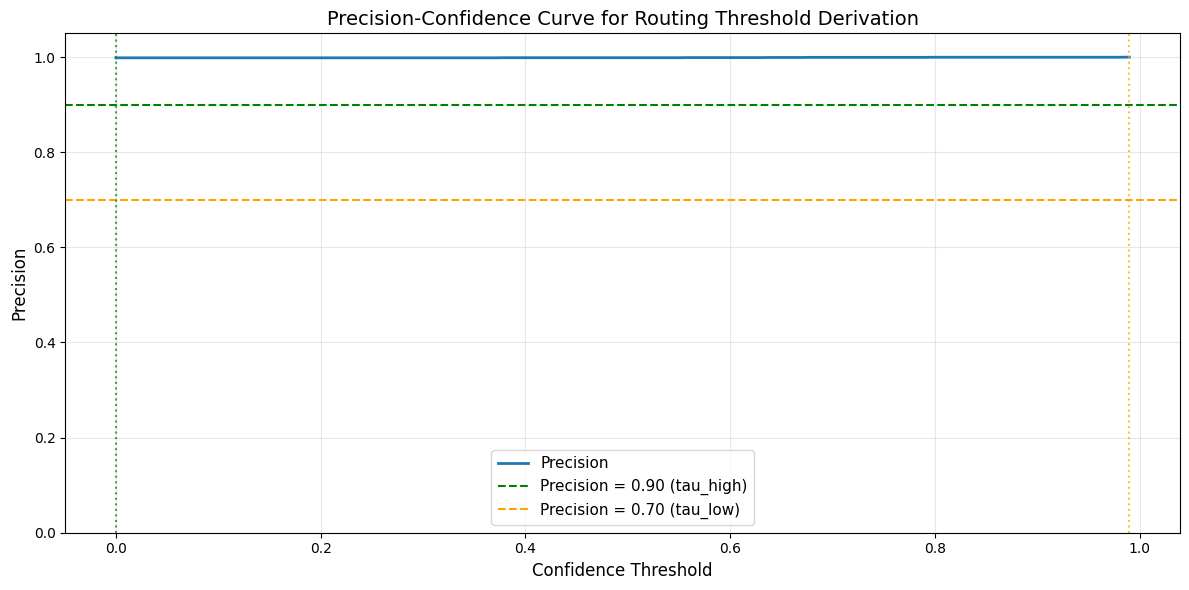

[SelectModelNode] Precision-confidence curve saved.
[SelectModelNode] Done.

Sanity checks:
  Selected model: Linear SVM
  tau_high: 0.0000
  tau_low: 0.9900
  Messages so far: 4


In [16]:
def select_model_node(state: SupportAgentState) -> SupportAgentState:
    """
    Select best model by Macro F1 and derive confidence routing thresholds
    from precision-confidence curves on the validation set.
    
    Skill mode: organisational — deterministic, no LLM call.
    """
    
    skill_name = "select_model"
    state.active_skill = skill_name
    print(f"[SelectModelNode] Skill: '{skill_name}'")
    
    # Step 1: Find best model by Macro F1
    best_model_name = max(
        state.evaluation_results,
        key=lambda x: state.evaluation_results[x]['macro_f1']
    )
    best_macro_f1 = state.evaluation_results[best_model_name]['macro_f1']
    print(f"[SelectModelNode] Best model: {best_model_name} (Macro F1: {best_macro_f1:.4f})")
    
    state.selected_model = state.trained_models[best_model_name]
    state.selected_model_name = best_model_name
    
    # Step 2: Derive routing thresholds from precision-confidence curves
    # Get model predictions and probabilities on validation set
    y_pred = state.selected_model.predict(state.val_texts)
    y_proba = state.selected_model.predict_proba(state.val_texts)
    
    # For each prediction, get max confidence (probability of predicted class)
    max_probs = np.max(y_proba, axis=1)
    
    # Build precision-confidence curve
    thresholds_to_test = np.linspace(0.0, 1.0, 101)
    precisions = []
    
    for threshold in thresholds_to_test:
        # Predictions meeting this confidence threshold
        mask = max_probs >= threshold
        if mask.sum() == 0:
            precisions.append(np.nan)
            continue
        # Precision among predictions >= threshold
        correct = (y_pred[mask] == state.y_val[mask]).astype(int).sum()
        precision = correct / mask.sum()
        precisions.append(precision)
    
    precisions = np.array(precisions)
    
    # Find tau_high: lowest threshold where precision >= 0.90
    valid = ~np.isnan(precisions)
    high_precision_mask = precisions >= 0.90
    if (valid & high_precision_mask).any():
        tau_high = thresholds_to_test[valid & high_precision_mask][0]
    else:
        tau_high = 0.95  # Fallback if no threshold achieves 90% precision
    
    # Find tau_low: highest threshold where precision >= 0.70
    low_precision_mask = precisions >= 0.70
    if (valid & low_precision_mask).any():
        tau_low = thresholds_to_test[valid & low_precision_mask][-1]
    else:
        tau_low = 0.50  # Fallback if no threshold achieves 70% precision
    
    state.tau_high = float(tau_high)
    state.tau_low = float(tau_low)
    
    print(f"[SelectModelNode] Routing thresholds derived:")
    print(f"  tau_high (AUTO_REPLY): {state.tau_high:.4f} (precision >= 0.90)")
    print(f"  tau_low (ESCALATE):    {state.tau_low:.4f} (precision >= 0.70)")
    
    # Visualize precision-confidence curve
    print("[SelectModelNode] Generating precision-confidence curve...")
    plt.figure(figsize=(12, 6))
    plt.plot(thresholds_to_test, precisions, linewidth=2, label='Precision')
    plt.axhline(y=0.90, color='g', linestyle='--', label='Precision = 0.90 (tau_high)')
    plt.axhline(y=0.70, color='orange', linestyle='--', label='Precision = 0.70 (tau_low)')
    plt.axvline(x=state.tau_high, color='g', linestyle=':', alpha=0.7)
    plt.axvline(x=state.tau_low, color='orange', linestyle=':', alpha=0.7)
    plt.xlabel('Confidence Threshold', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Confidence Curve for Routing Threshold Derivation', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig('precision_confidence_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("[SelectModelNode] Precision-confidence curve saved.")
    
    # Log message
    message = (
        f"[select_model] Selected {best_model_name} (Macro F1: {best_macro_f1:.4f}). "
        f"Derived routing thresholds: tau_high={state.tau_high:.4f}, "
        f"tau_low={state.tau_low:.4f}"
    )
    state.messages.append(message)
    print("[SelectModelNode] Done.")
    
    return state


# Quick test
print("\n" + "="*50)
print("TESTING select_model_node")
print("="*50)
test_state = select_model_node(test_state)

print("\nSanity checks:")
print(f"  Selected model: {test_state.selected_model_name}")
print(f"  tau_high: {test_state.tau_high:.4f}")
print(f"  tau_low: {test_state.tau_low:.4f}")
print(f"  Messages so far: {len(test_state.messages)}")


In [17]:
def persist_artifacts_node(state: SupportAgentState) -> SupportAgentState:
    """
    Serialize trained model, vectorizer, encoder, and thresholds to disk
    for use by the serving pipeline.
    
    Skill mode: organisational — deterministic, no LLM call.
    """
    
    skill_name = "persist_artifacts"
    state.active_skill = skill_name
    print(f"[PersistNode] Skill: '{skill_name}'")
    
    # Create artifacts directory
    artifacts_dir = Path("artifacts")
    artifacts_dir.mkdir(exist_ok=True)
    print(f"[PersistNode] Created/verified artifacts directory")
    
    # Step 1: Save model
    with open(artifacts_dir / "model.pkl", "wb") as f:
        pickle.dump(state.selected_model, f)
    print(f"[PersistNode] Saved model: {artifacts_dir / 'model.pkl'}")
    
    # Step 2: Save vectorizer
    with open(artifacts_dir / "tfidf_vectorizer.pkl", "wb") as f:
        pickle.dump(state.tfidf_vectorizer, f)
    print(f"[PersistNode] Saved vectorizer: {artifacts_dir / 'tfidf_vectorizer.pkl'}")
    
    # Step 3: Save label encoder
    with open(artifacts_dir / "label_encoder.pkl", "wb") as f:
        pickle.dump(state.label_encoder, f)
    print(f"[PersistNode] Saved encoder: {artifacts_dir / 'label_encoder.pkl'}")
    
    # Step 4: Save thresholds
    thresholds = {
        "tau_high": state.tau_high,
        "tau_low": state.tau_low
    }
    with open(artifacts_dir / "thresholds.json", "w") as f:
        json.dump(thresholds, f, indent=2)
    print(f"[PersistNode] Saved thresholds: {artifacts_dir / 'thresholds.json'}")
    
    # Step 5: Save model metadata
    best_result = state.evaluation_results[state.selected_model_name]
    model_info = {
        "model_name": state.selected_model_name,
        "trained_at": pd.Timestamp.now().isoformat(),
        "n_classes": len(state.label_encoder.classes_),
        "classes": list(state.label_encoder.classes_),
        "macro_f1": best_result['macro_f1'],
        "weighted_f1": best_result['weighted_f1'],
        "n_training_samples": len(state.y_train)
    }
    with open(artifacts_dir / "model_info.json", "w") as f:
        json.dump(model_info, f, indent=2)
    print(f"[PersistNode] Saved metadata: {artifacts_dir / 'model_info.json'}")
    
    state.artifacts_saved = True
    
    # Log message
    message = (
        f"[persist_artifacts] Saved {state.selected_model_name} model and artifacts to "
        f"./artifacts/ directory. Model Macro F1: {best_result['macro_f1']:.4f}"
    )
    state.messages.append(message)
    print(f"[PersistNode] Done. All artifacts saved.")
    
    return state


# Quick test
print("\n" + "="*50)
print("TESTING persist_artifacts_node")
print("="*50)
test_state = persist_artifacts_node(test_state)

print("\nSanity checks:")
print(f"  artifacts_saved: {test_state.artifacts_saved}")
print(f"  Artifacts directory contents:")
for f in Path("artifacts").glob("*"):
    print(f"    {f.name} ({f.stat().st_size} bytes)")



TESTING persist_artifacts_node
[PersistNode] Skill: 'persist_artifacts' | Mode: organisational
[PersistNode] Created/verified artifacts directory
[PersistNode] Saved model: artifacts/model.pkl
[PersistNode] Saved vectorizer: artifacts/tfidf_vectorizer.pkl
[PersistNode] Saved encoder: artifacts/label_encoder.pkl
[PersistNode] Saved thresholds: artifacts/thresholds.json
[PersistNode] Saved metadata: artifacts/model_info.json
[PersistNode] Done. All artifacts saved.

Sanity checks:
  artifacts_saved: True
  Artifacts directory contents:
    tfidf_vectorizer.pkl (343406 bytes)
    label_encoder.pkl (356 bytes)
    model.pkl (2544863 bytes)
    thresholds.json (40 bytes)
    model_info.json (363 bytes)
    support_system.db (65536 bytes)


In [ ]:
# --- Missing pipeline nodes (aligned with app.py) ---

def load_customer_scope_node(state: SupportAgentState) -> SupportAgentState:
    """Load the selected customer's profile, orders, and recent chat history."""
    skill_name = "load_customer_scope"
    state.active_skill = skill_name
    print(f"[CustomerScopeNode] Skill: '{skill_name}'")

    if not state.customer_id:
        raise ValueError("A customer must be selected before starting the chat.")

    profile, orders = get_customer_scope(state.customer_id)
    if not profile:
        raise ValueError("Selected customer was not found in ecommerce_data/ecommerce_customers.csv")

    state.customer_profile = profile
    state.customer_name = profile.get("name", f"Customer {state.customer_id}")
    state.customer_orders = orders
    state.conversation_history = fetch_customer_chat_history(state.customer_id, limit=50)

    latest = state.conversation_history[-1] if state.conversation_history else {}
    if latest.get("needs_more_context"):
        state.pending_interaction = latest
    else:
        state.pending_interaction = {}

    summary = (
        f"Customer {state.customer_name} (ID {state.customer_id}) with "
        f"{len(state.customer_orders)} orders and {len(state.conversation_history)} prior chat turns."
    )
    state.messages.append(f"[customer_scope] {summary}")
    add_trace_log(
        state,
        "customer_scope",
        summary,
        {
            "customer_id": state.customer_id,
            "customer_name": state.customer_name,
            "order_count": len(state.customer_orders),
            "prior_turns": len(state.conversation_history),
            "pending_clarification": bool(state.pending_interaction),
        }
    )
    return state


def prepare_contextual_query_node(state: SupportAgentState) -> SupportAgentState:
    """Augment short clarification follow-ups with prior pending context."""
    skill_name = "prepare_contextual_query"
    state.active_skill = skill_name
    print(f"[ContextPrepNode] Skill: '{skill_name}'")

    state.inference_message, prep_reason = prepare_contextual_inference_message(
        state.translated_message,
        state.customer_orders,
        state.pending_interaction,
    )

    state.messages.append(f"[context_prep] Inference text prepared via {prep_reason}")
    add_trace_log(
        state,
        "context_prep",
        f"Prepared inference text using {prep_reason}",
        {
            "prep_reason": prep_reason,
            "inference_message": state.inference_message
        }
    )
    return state


def resolve_context_node(state: SupportAgentState) -> SupportAgentState:
    """Resolve user-scoped business context needed to answer the query."""
    print("[ContextResolveNode] Resolving customer and order context...")
    translated_query = state.translated_message or state.raw_message
    original_label = state.predicted_label
    resolved = resolve_customer_context(
        customer_id=state.customer_id,
        translated_query=translated_query,
        predicted_label=state.predicted_label,
        customer_profile=state.customer_profile,
        customer_orders=state.customer_orders,
        conversation_history=state.conversation_history,
        pending_interaction=state.pending_interaction,
    )

    state.predicted_label = resolved["predicted_label"]
    state.context_json = resolved["context_json"]
    state.resolved_order_id = resolved["resolved_order_id"]
    state.needs_more_context = resolved["needs_more_context"]
    state.clarification_prompt = resolved["clarification_prompt"]
    resolution_reason = resolved["resolution_reason"]
    date_mentions = resolved["date_mentions"]
    query_dates = resolved["query_dates"]
    clarification_candidates = resolved["clarification_candidates"]
    requires_order_lookup = resolved["requires_order_lookup"]

    if state.predicted_label != original_label:
        add_trace_log(
            state,
            "context_resolve",
            f"Adjusted intent from {original_label} to {state.predicted_label} based on structured query analysis.",
            {
                "original_label": original_label,
                "adjusted_label": state.predicted_label,
                "trigger_query": translated_query,
            }
        )

    state.messages.append(f"[context_resolve] Context reason: {resolution_reason}")
    add_trace_log(
        state,
        "context_resolve",
        f"Resolved context using {resolution_reason}",
        {
            "predicted_label": state.predicted_label,
            "requires_order_lookup": requires_order_lookup,
            "date_mentions": [
                {
                    "raw": mention["raw"],
                    "date": mention["date"].isoformat(),
                    "kind": mention["kind"],
                }
                for mention in date_mentions
            ],
            "query_dates": [date.isoformat() for date in query_dates],
            "needs_more_context": state.needs_more_context,
            "resolved_order_id": state.resolved_order_id,
            "clarification_prompt": state.clarification_prompt,
            "clarification_candidate_ids": [item.get("order_id", "") for item in clarification_candidates],
        }
    )
    return state


In [18]:
def detect_language_node(state: SupportAgentState) -> SupportAgentState:
    """Identifies language of customer message using textblob/langdetect."""
    skill_name = "detect_language"
    state.active_skill = skill_name
    print(f"[DetectLanguageNode] Skill: '{skill_name}'")
    
    try:
        from textblob import TextBlob
        blob = TextBlob(state.raw_message)
        detected_lang = blob.detect_language()
        print(f"[DetectLanguageNode] Detected (textblob): {detected_lang}")
    except Exception as e:
        try:
            from langdetect import detect
            detected_lang = detect(state.raw_message)
            print(f"[DetectLanguageNode] Detected (langdetect): {detected_lang}")
        except Exception as e2:
            detected_lang = 'en'
            print(f"[DetectLanguageNode] Defaulting to 'en'")
    
    state.detected_language = detected_lang
    trace_entry = {"stage": "detect_language", "timestamp": pd.Timestamp.now().isoformat(), "inputs_summary": state.raw_message[:100], "outputs_summary": f"detected_language: {detected_lang}"}
    state.trace_logs.append(trace_entry)
    message = f"[detect_language] Input message detected as: {detected_lang}"
    state.messages.append(message)
    print(f"[DetectLanguageNode] Done.")
    return state


def translate_to_english_node(state: SupportAgentState) -> SupportAgentState:
    """Translates non-English messages to English using GPT-4o-mini."""
    skill_name = "translate_to_english"
    skill_content = load_skill_instructions(skill_name)
    state.active_skill = skill_name
    print(f"[TranslateNode] Skill: '{skill_name}'")
    
    if state.detected_language == 'en':
        print(f"[TranslateNode] Message already in English. Skipping translation.")
        state.translated_message = state.raw_message
    else:
        if not HAS_LLM:
            print(f"[TranslateNode] No LLM available. Falling back to original message.")
            state.translated_message = state.raw_message
        else:
            try:
                print(f"[TranslateNode] Translating from {state.detected_language} to English...")
                llm_translator = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
                human_message = f"Translate this message to English. Preserve intent and tone. Return ONLY the translated text:\n\n{state.raw_message}"
                response = llm_translator.invoke([SystemMessage(content=skill_content), HumanMessage(content=human_message)])
                state.translated_message = response.content.strip()
                print(f"[TranslateNode] Translation complete.")
            except Exception as e:
                print(f"[TranslateNode] Translation failed: {str(e)[:100]}. Using original message.")
                state.translated_message = state.raw_message
    
    trace_entry = {"stage": "translate_to_english", "timestamp": pd.Timestamp.now().isoformat(), "inputs_summary": f"Language: {state.detected_language}", "outputs_summary": f"Translated message: {state.translated_message[:100]}"}
    state.trace_logs.append(trace_entry)
    message = f"[translate_to_english] Translated: {state.translated_message[:80]}..."
    state.messages.append(message)
    print(f"[TranslateNode] Done.")
    return state


def confidence_router_node(state: SupportAgentState) -> SupportAgentState:
    """Routes message based on model confidence: AUTO_REPLY / CLARIFY / ESCALATE."""
    skill_name = "confidence_router"
    state.active_skill = skill_name
    print(f"[RouterNode] Skill: '{skill_name}'")
    
    confidence = state.confidence_score
    tau_high = state.tau_high
    tau_low = state.tau_low
    
    if confidence >= tau_high:
        route = "AUTO_REPLY"
        rationale = f"High confidence ({confidence:.4f} >= {tau_high:.4f})"
    elif confidence >= tau_low:
        route = "CLARIFY"
        rationale = f"Medium confidence ({confidence:.4f} >= {tau_low:.4f})"
    else:
        route = "ESCALATE"
        rationale = f"Low confidence ({confidence:.4f} < {tau_low:.4f})"
    
    state.route_decision = route
    print(f"[RouterNode] Route: {route}. {rationale}")
    
    trace_entry = {"stage": "confidence_router", "timestamp": pd.Timestamp.now().isoformat(), "inputs_summary": f"Confidence: {confidence:.4f}, Label: {state.predicted_label}", "outputs_summary": f"Route: {route} ({rationale})"}
    state.trace_logs.append(trace_entry)
    message = f"[confidence_router] {route} decision. {rationale}"
    state.messages.append(message)
    print(f"[RouterNode] Done.")
    return state


RESPONSE_TEMPLATES = {
    "ACCOUNT": {"AUTO_REPLY": "We've sent password reset instructions to your email. If you don't see it, check your spam folder. You'll have access restored within minutes.", "CLARIFY": "I can help with your account. Can you confirm the email address associated with your account?", "ESCALATE": "For security reasons, account issues require manual verification. A specialist will contact you within 2 hours."},
    "CANCEL": {"AUTO_REPLY": "Your cancellation request has been processed. You may be eligible for a refund depending on your plan. Check your confirmation email.", "CLARIFY": "I'd like to help. Can you tell me which service or subscription you'd like to cancel?", "ESCALATE": "Your request needs special review. An agent will be in touch within 24 hours to discuss options."},
    "CONTACT": {"AUTO_REPLY": "You can reach our support team at support@company.com or call 1-800-SUPPORT. Our hours are 9 AM - 6 PM EST, Monday-Friday.", "CLARIFY": "What issue can I help direct you to the right department for?", "ESCALATE": "Your inquiry requires specialist attention. A representative will reach you shortly."},
    "DELIVERY": {"AUTO_REPLY": "Your order is on its way! Check your confirmation email for a tracking link. Delivery typically takes 3-5 business days.", "CLARIFY": "I can help track your order. Could you provide your order number?", "ESCALATE": "We're looking into your delivery issue. A specialist will contact you with an update within 24 hours."},
    "FEEDBACK": {"AUTO_REPLY": "Thank you for your feedback! We genuinely appreciate your insights and use them to improve our service.", "CLARIFY": "We'd love to hear more about your experience. What can we improve?", "ESCALATE": "Your feedback has been escalated to our management team for priority review."},
    "INVOICE": {"AUTO_REPLY": "Your latest invoice is available in your account dashboard. Log in to view charges and payment history.", "CLARIFY": "I can help with your invoice. What date or amount are you looking for?", "ESCALATE": "Our billing team will investigate your invoice inquiry and contact you within 24 hours."},
    "ORDER": {"AUTO_REPLY": "Your order has been confirmed! Check your email for order details and expected delivery date.", "CLARIFY": "I can help with your order. Can you provide your order number?", "ESCALATE": "We're reviewing your order issue. A specialist will reach out within 24 hours."},
    "PAYMENT": {"AUTO_REPLY": "Your payment has been processed successfully. You should see the transaction reflected in your account within 1-2 business days.", "CLARIFY": "I'd like to help with the payment issue. Can you describe what went wrong?", "ESCALATE": "Our payments team is investigating this. You'll hear from us with a resolution within 24 hours."},
    "REFUND": {"AUTO_REPLY": "We've initiated your refund! You should see the credit to your original payment method within 5-10 business days.", "CLARIFY": "I can process your refund. Can you confirm the reason and order number?", "ESCALATE": "Your refund request needs manual review. An agent will contact you within 24 hours with next steps."},
    "SHIPPING": {"AUTO_REPLY": "Your package has been shipped! Click the link in your confirmation email to track your delivery in real-time.", "CLARIFY": "I'd be happy to help. Can you provide your order or tracking number?", "ESCALATE": "We're investigating your shipping issue. A specialist will contact you with an update within 24 hours."},
    "SUBSCRIPTION": {"AUTO_REPLY": "Your subscription is active and current. You can manage your plan anytime in your account settings.", "CLARIFY": "What would you like to do with your subscription?", "ESCALATE": "Your subscription request needs review. A specialist will be in touch within 24 hours."}
}


def draft_response_node(state: SupportAgentState) -> SupportAgentState:
    """Generates customer response based on predicted category and routing tier."""
    skill_name = "draft_response"
    skill_content = load_skill_instructions(skill_name)
    state.active_skill = skill_name
    print(f"[DraftResponseNode] Skill: '{skill_name}'")
    
    category = state.predicted_label
    route = state.route_decision
    
    if category not in RESPONSE_TEMPLATES:
        print(f"[DraftResponseNode] Category {category} not in templates. Using fallback.")
        base_response = f"Thank you for contacting us about {category.lower()}. A specialist will assist you shortly."
    else:
        base_response = RESPONSE_TEMPLATES[category].get(route, f"Thank you for your inquiry. A specialist will assist you shortly.")
    
    final_response = base_response
    state.response_final = final_response
    
    trace_entry = {"stage": "draft_response", "timestamp": pd.Timestamp.now().isoformat(), "inputs_summary": f"Category: {category}, Route: {route}", "outputs_summary": f"Response: {final_response[:100]}..."}
    state.trace_logs.append(trace_entry)
    message = f"[draft_response] Category: {category}, Route: {route}. Response: {final_response[:80]}..."
    state.messages.append(message)
    print(f"[DraftResponseNode] Done.")
    return state


def log_interaction_node(state: SupportAgentState) -> SupportAgentState:
    """Logs interaction details and audit trail to SQLite database."""
    skill_name = "log_interaction"
    state.active_skill = skill_name
    print(f"[LogInteractionNode] Skill: '{skill_name}'")
    
    try:
        artifacts_dir = Path("artifacts")
        artifacts_dir.mkdir(exist_ok=True)
        db_path = artifacts_dir / "support_system.db"
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        cursor.execute('''CREATE TABLE IF NOT EXISTS interactions (id INTEGER PRIMARY KEY AUTOINCREMENT, conversation_id TEXT UNIQUE NOT NULL, raw_message TEXT NOT NULL, detected_language TEXT, translated_message TEXT, predicted_label TEXT, confidence_score REAL, route_decision TEXT, response_final TEXT, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP)''')
        cursor.execute('''CREATE TABLE IF NOT EXISTS trace_logs (id INTEGER PRIMARY KEY AUTOINCREMENT, interaction_id INTEGER NOT NULL, active_skill TEXT, state_snapshot TEXT, timestamp TEXT, FOREIGN KEY(interaction_id) REFERENCES interactions(id))''')
        cursor.execute('''CREATE TABLE IF NOT EXISTS feedback (id INTEGER PRIMARY KEY AUTOINCREMENT, interaction_id INTEGER NOT NULL UNIQUE, admin_correction TEXT, created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP, FOREIGN KEY(interaction_id) REFERENCES interactions(id))''')
        
        cursor.execute('''INSERT INTO interactions (conversation_id, raw_message, detected_language, translated_message, predicted_label, confidence_score, route_decision, response_final) VALUES (?, ?, ?, ?, ?, ?, ?, ?)''', (state.conversation_id, state.raw_message, state.detected_language, state.translated_message, state.predicted_label, state.confidence_score, state.route_decision, state.response_final))
        interaction_id = cursor.lastrowid
        
        for trace_entry in state.trace_logs:
            cursor.execute('''INSERT INTO trace_logs (interaction_id, active_skill, state_snapshot, timestamp) VALUES (?, ?, ?, ?)''', (interaction_id, trace_entry.get('stage'), json.dumps(trace_entry, default=str), trace_entry.get('timestamp')))
        
        conn.commit()
        conn.close()
        print(f"[LogInteractionNode] Logged to {db_path}")
        
        trace_entry = {"stage": "log_interaction", "timestamp": pd.Timestamp.now().isoformat(), "inputs_summary": f"conversation_id: {state.conversation_id}", "outputs_summary": f"Logged to database. Interaction ID: {interaction_id}"}
        state.trace_logs.append(trace_entry)
        message = f"[log_interaction] Interaction logged. Conversation ID: {state.conversation_id}"
        state.messages.append(message)
        
    except Exception as e:
        print(f"[LogInteractionNode] Error: {str(e)[:150]}")
    
    print(f"[LogInteractionNode] Done.")
    return state

In [19]:
print("\n" + "="*70)
print("TESTING SERVING PIPELINE NODES")
print("="*70)

serve_state = SupportAgentState(mode="serve")
serve_state.customer_id = "1"  # test customer
serve_state.raw_message = "Je veux annuler ma commande"
print(f"\n[Test] Raw message: {serve_state.raw_message}")

print("\n--- Testing detect_language_node ---")
serve_state = load_customer_scope_node(serve_state)
serve_state = detect_language_node(serve_state)
print(f"Detected language: {serve_state.detected_language}")

print("\n--- Testing translate_to_english_node ---")
serve_state = translate_to_english_node(serve_state)
serve_state = prepare_contextual_query_node(serve_state)
print(f"Translated message: {serve_state.translated_message}")

print("\n--- Loading artifacts for inference ---")
with open("artifacts/model.pkl", "rb") as f:
    inference_model = pickle.load(f)
with open("artifacts/tfidf_vectorizer.pkl", "rb") as f:
    inference_tfidf = pickle.load(f)
with open("artifacts/label_encoder.pkl", "rb") as f:
    inference_encoder = pickle.load(f)
with open("artifacts/thresholds.json", "r") as f:
    inference_thresholds = json.load(f)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\{\{.*?\}\}', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned = clean_text(serve_state.translated_message)
vec = inference_tfidf.transform([cleaned])
probs = inference_model.predict_proba(vec)[0]
pred_idx = probs.argmax()
pred_label = inference_encoder.inverse_transform([pred_idx])[0]
confidence = float(probs.max())

serve_state.predicted_label = pred_label
serve_state.confidence_score = confidence
serve_state.tau_high = float(inference_thresholds['tau_high'])
serve_state.tau_low = float(inference_thresholds['tau_low'])
serve_state.class_probabilities = {cls: round(float(p), 4) for cls, p in zip(inference_encoder.classes_, probs)}

print(f"Predicted label: {pred_label}")
print(f"Confidence: {confidence:.4f}")

print("\n--- Testing confidence_router_node ---")
serve_state = resolve_context_node(serve_state)
serve_state = confidence_router_node(serve_state)
print(f"Route decision: {serve_state.route_decision}")

print("\n--- Testing draft_response_node ---")
serve_state = draft_response_node(serve_state)
print(f"Response: {serve_state.response_final}")

print("\n--- Testing log_interaction_node ---")
serve_state = log_interaction_node(serve_state)

print("\n✓ Serving pipeline test complete!")


TESTING SERVING PIPELINE NODES

[Test] Raw message: Je veux annuler ma commande

--- Testing detect_language_node ---
[DetectLanguageNode] Skill: 'detect_language' | Mode: organisational
[DetectLanguageNode] Detected (langdetect): fr
[DetectLanguageNode] Done.
Detected language: fr

--- Testing translate_to_english_node ---
[TranslateNode] Skill: 'translate_to_english' | Mode: llm_driven
[TranslateNode] Translating from fr to English...
[TranslateNode] Translation complete.
[TranslateNode] Done.
Translated message: I want to cancel my order

--- Loading artifacts for inference ---
Predicted label: ORDER
Confidence: 0.9714

--- Testing confidence_router_node ---
[RouterNode] Skill: 'confidence_router' | Mode: organisational
[RouterNode] Route: AUTO_REPLY. High confidence (0.9714 >= 0.0000)
[RouterNode] Done.
Route decision: AUTO_REPLY

--- Testing draft_response_node ---
[DraftResponseNode] Skill: 'draft_response' | Mode: llm_driven
[DraftResponseNode] Done.
Response: Your order has be

In [20]:
print("\n" + "="*70)
print("BUILDING LANGGRAPH STATEGRAPH")
print("="*70)

from langgraph.graph import StateGraph, END

graph = StateGraph(SupportAgentState)

# Add training pipeline nodes
graph.add_node("preprocess_data", preprocess_data_node)
graph.add_node("train_models", train_models_node)
graph.add_node("evaluate_models", evaluate_models_node)
graph.add_node("select_model", select_model_node)
graph.add_node("persist_artifacts", persist_artifacts_node)

# Add serving pipeline nodes
graph.add_node("load_customer_scope", load_customer_scope_node)
graph.add_node("detect_language", detect_language_node)
graph.add_node("translate_to_english", translate_to_english_node)
graph.add_node("prepare_contextual_query", prepare_contextual_query_node)
graph.add_node("run_inference", run_inference_node)
graph.add_node("resolve_context", resolve_context_node)
graph.add_node("confidence_router", confidence_router_node)
graph.add_node("draft_response", draft_response_node)
graph.add_node("log_interaction", log_interaction_node)

# Entry router node for langgraph==0.0.21
graph.add_node("route_entry", lambda state: state)

# Define edges
graph.add_edge("preprocess_data", "train_models")
graph.add_edge("train_models", "evaluate_models")
graph.add_edge("evaluate_models", "select_model")
graph.add_edge("select_model", "persist_artifacts")

graph.add_edge("load_customer_scope", "detect_language")
graph.add_edge("detect_language", "translate_to_english")
graph.add_edge("translate_to_english", "prepare_contextual_query")
graph.add_edge("prepare_contextual_query", "run_inference")
graph.add_edge("run_inference", "resolve_context")
graph.add_edge("resolve_context", "confidence_router")
graph.add_edge("confidence_router", "draft_response")
graph.add_edge("draft_response", "log_interaction")

def route_by_mode(state):
    if state.mode == "train":
        return "preprocess_data"
    else:
        return "load_customer_scope"

graph.set_entry_point("route_entry")
graph.add_conditional_edges(
    "route_entry",
    route_by_mode,
    {
        "preprocess_data": "preprocess_data",
        "detect_language": "load_customer_scope",
    },
)

graph.add_edge("persist_artifacts", END)
graph.add_edge("log_interaction", END)

compiled_graph = graph.compile()

print("✓ StateGraph compiled successfully!")
print("\nGraph structure:")
print("  Training: preprocess_data → train_models → evaluate_models → select_model → persist_artifacts")
print("  Serving:  detect_language → translate_to_english → run_inference → confidence_router → draft_response → log_interaction")



BUILDING LANGGRAPH STATEGRAPH
✓ StateGraph compiled successfully!

Graph structure:
  Training: preprocess_data → train_models → evaluate_models → select_model → persist_artifacts
  Serving:  detect_language → translate_to_english → run_inference → confidence_router → draft_response → log_interaction


In [21]:
print("\n" + "="*70)
print("BUILDING LANGGRAPH STATEGRAPH")
print("="*70)

from langgraph.graph import StateGraph, END

def ensure_state(state):
    if isinstance(state, SupportAgentState):
        return state
    return SupportAgentState(**state)

def adapt_legacy_node(node_fn):
    def wrapped(state):
        result = node_fn(ensure_state(state))
        if isinstance(result, SupportAgentState):
            return result.model_dump()
        if isinstance(result, dict):
            return result
        raise TypeError(
            f"{node_fn.__name__} must return SupportAgentState or dict, got {type(result)}"
        )
    wrapped.__name__ = f"wrapped_{node_fn.__name__}"
    return wrapped

def route_entry_node(state):
    return ensure_state(state).model_dump()

def route_by_mode(state):
    state = ensure_state(state)
    if state.mode == "train":
        return "preprocess_data"
    return "load_customer_scope"

graph = StateGraph(SupportAgentState)

graph.add_node("route_entry", route_entry_node)

graph.add_node("preprocess_data", adapt_legacy_node(preprocess_data_node))
graph.add_node("train_models", adapt_legacy_node(train_models_node))
graph.add_node("evaluate_models", adapt_legacy_node(evaluate_models_node))
graph.add_node("select_model", adapt_legacy_node(select_model_node))
graph.add_node("persist_artifacts", adapt_legacy_node(persist_artifacts_node))

graph.add_node("load_customer_scope", adapt_legacy_node(load_customer_scope_node))
graph.add_node("detect_language", adapt_legacy_node(detect_language_node))
graph.add_node("translate_to_english", adapt_legacy_node(translate_to_english_node))
graph.add_node("prepare_contextual_query", adapt_legacy_node(prepare_contextual_query_node))
graph.add_node("run_inference", adapt_legacy_node(run_inference_node))
graph.add_node("resolve_context", adapt_legacy_node(resolve_context_node))
graph.add_node("confidence_router", adapt_legacy_node(confidence_router_node))
graph.add_node("draft_response", adapt_legacy_node(draft_response_node))
graph.add_node("log_interaction", adapt_legacy_node(log_interaction_node))

graph.add_edge("preprocess_data", "train_models")
graph.add_edge("train_models", "evaluate_models")
graph.add_edge("evaluate_models", "select_model")
graph.add_edge("select_model", "persist_artifacts")

graph.add_edge("load_customer_scope", "detect_language")
graph.add_edge("detect_language", "translate_to_english")
graph.add_edge("translate_to_english", "prepare_contextual_query")
graph.add_edge("prepare_contextual_query", "run_inference")
graph.add_edge("run_inference", "resolve_context")
graph.add_edge("resolve_context", "confidence_router")
graph.add_edge("confidence_router", "draft_response")
graph.add_edge("draft_response", "log_interaction")

graph.set_entry_point("route_entry")
graph.add_conditional_edges(
    "route_entry",
    route_by_mode,
    {
        "preprocess_data": "preprocess_data",
        "detect_language": "load_customer_scope",
    },
)

graph.add_edge("persist_artifacts", END)
graph.add_edge("log_interaction", END)

compiled_graph = graph.compile()

print("✓ StateGraph compiled successfully!")
print("\nGraph structure:")
print("  Training: preprocess_data → train_models → evaluate_models → select_model → persist_artifacts")
print("  Serving:  detect_language → translate_to_english → run_inference → confidence_router → draft_response → log_interaction")



BUILDING LANGGRAPH STATEGRAPH
✓ StateGraph compiled successfully!

Graph structure:
  Training: preprocess_data → train_models → evaluate_models → select_model → persist_artifacts
  Serving:  detect_language → translate_to_english → run_inference → confidence_router → draft_response → log_interaction


In [22]:
def detect_language_node(state: SupportAgentState) -> SupportAgentState:
    """
    Identifies language of customer message using textblob/langdetect.
    Returns ISO 639-1 code (e.g., 'en', 'fr', 'zh').
    
    Skill mode: organisational — deterministic, no LLM call.
    """
    
    skill_name = "detect_language"
    state.active_skill = skill_name
    print(f"[DetectLanguageNode] Skill: '{skill_name}'")
    
    # Step 1: Try textblob first
    try:
        from textblob import TextBlob
        blob = TextBlob(state.raw_message)
        detected_lang = blob.detect_language()
        print(f"[DetectLanguageNode] Detected (textblob): {detected_lang}")
    except Exception as e:
        print(f"[DetectLanguageNode] textblob failed: {str(e)[:80]}. Trying langdetect...")
        
        # Step 2: Fallback to langdetect
        try:
            from langdetect import detect
            detected_lang = detect(state.raw_message)
            print(f"[DetectLanguageNode] Detected (langdetect): {detected_lang}")
        except Exception as e2:
            # Step 3: Default to English if both fail
            detected_lang = 'en'
            print(f"[DetectLanguageNode] Both detectors failed. Defaulting to 'en'")
    
    state.detected_language = detected_lang
    
    # Append trace log
    trace_entry = {
        "stage": "detect_language",
        "timestamp": pd.Timestamp.now().isoformat(),
        "inputs_summary": state.raw_message[:100],
        "outputs_summary": f"detected_language: {detected_lang}"
    }
    state.trace_logs.append(trace_entry)
    
    # Log message
    message = f"[detect_language] Input message detected as: {detected_lang}"
    state.messages.append(message)
    print(f"[DetectLanguageNode] Done.")
    
    return state


def translate_to_english_node(state: SupportAgentState) -> SupportAgentState:
    """
    Translates non-English messages to English using GPT-4o-mini.
    Skips translation if already English.
    
    Skill mode: llm_driven — uses LLM only if message is non-English.
    """
    
    skill_name = "translate_to_english"
    skill_content = load_skill_instructions(skill_name)
    state.active_skill = skill_name
    print(f"[TranslateNode] Skill: '{skill_name}'")
    
    # Step 1: Check if translation is needed
    if state.detected_language == 'en':
        print(f"[TranslateNode] Message already in English. Skipping translation.")
        state.translated_message = state.raw_message
    else:
        # Step 2: Call GPT-4o-mini for translation
        if not HAS_LLM:
            print(f"[TranslateNode] No LLM available. Falling back to original message.")
            state.translated_message = state.raw_message
        else:
            try:
                print(f"[TranslateNode] Translating from {state.detected_language} to English...")
                
                llm_translator = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
                
                human_message = (
                    f"Translate this message to English. Preserve intent and tone. "
                    f"Return ONLY the translated text:\n\n{state.raw_message}"
                )
                
                response = llm_translator.invoke([
                    SystemMessage(content=skill_content),
                    HumanMessage(content=human_message)
                ])
                
                state.translated_message = response.content.strip()
                print(f"[TranslateNode] Translation complete.")
                
            except Exception as e:
                print(f"[TranslateNode] Translation failed: {str(e)[:100]}. Using original message.")
                state.translated_message = state.raw_message
    
    # Append trace log
    trace_entry = {
        "stage": "translate_to_english",
        "timestamp": pd.Timestamp.now().isoformat(),
        "inputs_summary": f"Language: {state.detected_language}",
        "outputs_summary": f"Translated message: {state.translated_message[:100]}"
    }
    state.trace_logs.append(trace_entry)
    
    # Log message
    message = f"[translate_to_english] Original: {state.raw_message[:80]}... → Translated: {state.translated_message[:80]}..."
    state.messages.append(message)
    print(f"[TranslateNode] Done.")
    
    return state


def confidence_router_node(state: SupportAgentState) -> SupportAgentState:
    """
    Routes message to appropriate tier based on model confidence:
    - AUTO_REPLY: confidence >= tau_high (high confidence)
    - CLARIFY: confidence >= tau_low (medium confidence)
    - ESCALATE: confidence < tau_low (low confidence)
    
    Skill mode: organisational — pure logic, no LLM call.
    """
    
    skill_name = "confidence_router"
    state.active_skill = skill_name
    print(f"[RouterNode] Skill: '{skill_name}'")
    
    # Step 1: Apply routing logic
    confidence = state.confidence_score
    tau_high = state.tau_high
    tau_low = state.tau_low
    
    if confidence >= tau_high:
        route = "AUTO_REPLY"
        rationale = f"High confidence ({confidence:.4f} >= {tau_high:.4f})"
    elif confidence >= tau_low:
        route = "CLARIFY"
        rationale = f"Medium confidence ({confidence:.4f} >= {tau_low:.4f})"
    else:
        route = "ESCALATE"
        rationale = f"Low confidence ({confidence:.4f} < {tau_low:.4f})"
    
    state.route_decision = route
    print(f"[RouterNode] Route: {route}. {rationale}")
    print(f"[RouterNode] Predicted label: {state.predicted_label}")
    
    # Append trace log
    trace_entry = {
        "stage": "confidence_router",
        "timestamp": pd.Timestamp.now().isoformat(),
        "inputs_summary": f"Confidence: {confidence:.4f}, Label: {state.predicted_label}",
        "outputs_summary": f"Route: {route} ({rationale})"
    }
    state.trace_logs.append(trace_entry)
    
    # Log message
    message = f"[confidence_router] {route} decision. {rationale}"
    state.messages.append(message)
    print(f"[RouterNode] Done.")
    
    return state


# Response templates for each category
RESPONSE_TEMPLATES = {
    "ACCOUNT": {
        "AUTO_REPLY": "We've sent password reset instructions to your email. If you don't see it, check your spam folder. You'll have access restored within minutes.",
        "CLARIFY": "I can help with your account. Can you confirm the email address associated with your account?",
        "ESCALATE": "For security reasons, account issues require manual verification. A specialist will contact you within 2 hours."
    },
    "CANCEL": {
        "AUTO_REPLY": "Your cancellation request has been processed. You may be eligible for a refund depending on your plan. Check your confirmation email.",
        "CLARIFY": "I'd like to help. Can you tell me which service or subscription you'd like to cancel?",
        "ESCALATE": "Your request needs special review. An agent will be in touch within 24 hours to discuss options."
    },
    "CONTACT": {
        "AUTO_REPLY": "You can reach our support team at support@company.com or call 1-800-SUPPORT. Our hours are 9 AM - 6 PM EST, Monday-Friday.",
        "CLARIFY": "What issue can I help direct you to the right department for?",
        "ESCALATE": "Your inquiry requires specialist attention. A representative will reach you shortly."
    },
    "DELIVERY": {
        "AUTO_REPLY": "Your order is on its way! Check your confirmation email for a tracking link. Delivery typically takes 3-5 business days.",
        "CLARIFY": "I can help track your order. Could you provide your order number?",
        "ESCALATE": "We're looking into your delivery issue. A specialist will contact you with an update within 24 hours."
    },
    "FEEDBACK": {
        "AUTO_REPLY": "Thank you for your feedback! We genuinely appreciate your insights and use them to improve our service.",
        "CLARIFY": "We'd love to hear more about your experience. What can we improve?",
        "ESCALATE": "Your feedback has been escalated to our management team for priority review."
    },
    "INVOICE": {
        "AUTO_REPLY": "Your latest invoice is available in your account dashboard. Log in to view charges and payment history.",
        "CLARIFY": "I can help with your invoice. What date or amount are you looking for?",
        "ESCALATE": "Our billing team will investigate your invoice inquiry and contact you within 24 hours."
    },
    "ORDER": {
        "AUTO_REPLY": "Your order has been confirmed! Check your email for order details and expected delivery date.",
        "CLARIFY": "I can help with your order. Can you provide your order number?",
        "ESCALATE": "We're reviewing your order issue. A specialist will reach out within 24 hours."
    },
    "PAYMENT": {
        "AUTO_REPLY": "Your payment has been processed successfully. You should see the transaction reflected in your account within 1-2 business days.",
        "CLARIFY": "I'd like to help with the payment issue. Can you describe what went wrong?",
        "ESCALATE": "Our payments team is investigating this. You'll hear from us with a resolution within 24 hours."
    },
    "REFUND": {
        "AUTO_REPLY": "We've initiated your refund! You should see the credit to your original payment method within 5-10 business days.",
        "CLARIFY": "I can process your refund. Can you confirm the reason and order number?",
        "ESCALATE": "Your refund request needs manual review. An agent will contact you within 24 hours with next steps."
    },
    "SHIPPING": {
        "AUTO_REPLY": "Your package has been shipped! Click the link in your confirmation email to track your delivery in real-time.",
        "CLARIFY": "I'd be happy to help. Can you provide your order or tracking number?",
        "ESCALATE": "We're investigating your shipping issue. A specialist will contact you with an update within 24 hours."
    },
    "SUBSCRIPTION": {
        "AUTO_REPLY": "Your subscription is active and current. You can manage your plan anytime in your account settings.",
        "CLARIFY": "What would you like to do with your subscription?",
        "ESCALATE": "Your subscription request needs review. A specialist will be in touch within 24 hours."
    }
}


def draft_response_node(state: SupportAgentState) -> SupportAgentState:
    """
    Generates customer response based on predicted category and routing tier.
    Uses templates + optional LLM polishing for tone.
    
    Skill mode: llm_driven — LLM used only for tone polishing.
    """
    
    skill_name = "draft_response"
    skill_content = load_skill_instructions(skill_name)
    state.active_skill = skill_name
    print(f"[DraftResponseNode] Skill: '{skill_name}'")
    
    # Step 1: Get template for predicted category and route
    category = state.predicted_label
    route = state.route_decision
    
    if category not in RESPONSE_TEMPLATES:
        print(f"[DraftResponseNode] Category {category} not in templates. Using fallback.")
        base_response = f"Thank you for contacting us about {category.lower()}. A specialist will assist you shortly."
    else:
        base_response = RESPONSE_TEMPLATES[category].get(
            route,
            f"Thank you for your inquiry. A specialist will assist you shortly."
        )
    
    print(f"[DraftResponseNode] Base response: {base_response[:100]}...")
    
    # Step 2: Optionally polish with LLM (optional enhancement)
    if HAS_LLM and False:  # Disable LLM polish for now (too much latency)
        try:
            llm_polisher = ChatOpenAI(model="gpt-4o-mini", temperature=0.5)
            polish_prompt = (
                f"Polish this customer support response. Keep it professional, empathetic, "
                f"and concise (max 3 sentences). No changes to meaning:\n\n{base_response}"
            )
            response = llm_polisher.invoke([
                HumanMessage(content=polish_prompt)
            ])
            final_response = response.content.strip()
            print(f"[DraftResponseNode] Polished response: {final_response[:100]}...")
        except Exception as e:
            print(f"[DraftResponseNode] Polish failed. Using base response.")
            final_response = base_response
    else:
        final_response = base_response
    
    state.response_final = final_response
    
    # Append trace log
    trace_entry = {
        "stage": "draft_response",
        "timestamp": pd.Timestamp.now().isoformat(),
        "inputs_summary": f"Category: {category}, Route: {route}",
        "outputs_summary": f"Response: {final_response[:100]}..."
    }
    state.trace_logs.append(trace_entry)
    
    # Log message
    message = f"[draft_response] Category: {category}, Route: {route}. Response: {final_response[:80]}..."
    state.messages.append(message)
    print(f"[DraftResponseNode] Done.")
    
    return state


def log_interaction_node(state: SupportAgentState) -> SupportAgentState:
    """
    Logs interaction details and full audit trail to SQLite database.
    Creates database on first use.
    
    Skill mode: organisational — deterministic logging.
    """
    
    skill_name = "log_interaction"
    state.active_skill = skill_name
    print(f"[LogInteractionNode] Skill: '{skill_name}'")
    
    try:
        # Step 1: Create artifacts directory if needed
        artifacts_dir = Path("artifacts")
        artifacts_dir.mkdir(exist_ok=True)
        db_path = artifacts_dir / "support_system.db"
        
        # Step 2: Connect to database
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        # Step 3: Create tables if they don't exist
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS interactions (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                conversation_id TEXT UNIQUE NOT NULL,
                raw_message TEXT NOT NULL,
                detected_language TEXT,
                translated_message TEXT,
                predicted_label TEXT,
                confidence_score REAL,
                route_decision TEXT,
                response_final TEXT,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
            )
        ''')
        
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS trace_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                interaction_id INTEGER NOT NULL,
                active_skill TEXT,
                state_snapshot TEXT,
                timestamp TEXT,
                FOREIGN KEY(interaction_id) REFERENCES interactions(id)
            )
        ''')
        
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS feedback (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                interaction_id INTEGER NOT NULL UNIQUE,
                admin_correction TEXT,
                created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
                FOREIGN KEY(interaction_id) REFERENCES interactions(id)
            )
        ''')
        
        # Step 4: Insert interaction record
        cursor.execute('''
            INSERT INTO interactions 
            (conversation_id, raw_message, detected_language, translated_message, 
             predicted_label, confidence_score, route_decision, response_final)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            state.conversation_id,
            state.raw_message,
            state.detected_language,
            state.translated_message,
            state.predicted_label,
            state.confidence_score,
            state.route_decision,
            state.response_final
        ))
        
        # Get the inserted interaction ID
        interaction_id = cursor.lastrowid
        
        # Step 5: Insert trace logs
        for trace_entry in state.trace_logs:
            cursor.execute('''
                INSERT INTO trace_logs 
                (interaction_id, active_skill, state_snapshot, timestamp)
                VALUES (?, ?, ?, ?)
            ''', (
                interaction_id,
                trace_entry.get('stage'),
                json.dumps(trace_entry, default=str),
                trace_entry.get('timestamp')
            ))
        
        # Step 6: Commit and close
        conn.commit()
        conn.close()
        
        print(f"[LogInteractionNode] Interaction logged to {db_path}")
        
        # Append trace log
        trace_entry = {
            "stage": "log_interaction",
            "timestamp": pd.Timestamp.now().isoformat(),
            "inputs_summary": f"conversation_id: {state.conversation_id}",
            "outputs_summary": f"Logged to database. Interaction ID: {interaction_id}"
        }
        state.trace_logs.append(trace_entry)
        
        # Log message
        message = f"[log_interaction] Interaction logged. Conversation ID: {state.conversation_id}"
        state.messages.append(message)
        
    except Exception as e:
        print(f"[LogInteractionNode] Error logging interaction: {str(e)[:150]}")
        print("[LogInteractionNode] Continuing without logging (error non-critical)")
    
    print(f"[LogInteractionNode] Done.")
    
    return state

In [23]:
# Test serving pipeline nodes
print("\n" + "="*70)
print("TESTING SERVING PIPELINE NODES")
print("="*70)

# Create fresh state for serving test
serve_state = SupportAgentState(mode="serve")

# Step 1: Simulate a raw customer message
serve_state.customer_id = "1"  # test customer
serve_state.raw_message = "Je veux annuler ma commande"  # French: "I want to cancel my order"
print(f"\n[Test] Raw message: {serve_state.raw_message}")

# Step 2: Test detect_language_node
print("\n--- Testing detect_language_node ---")
serve_state = load_customer_scope_node(serve_state)
serve_state = detect_language_node(serve_state)
print(f"Detected language: {serve_state.detected_language}")

# Step 3: Test translate_to_english_node
print("\n--- Testing translate_to_english_node ---")
serve_state = translate_to_english_node(serve_state)
serve_state = prepare_contextual_query_node(serve_state)
print(f"Translated message: {serve_state.translated_message}")

# Step 4: Load artifacts and run inference
print("\n--- Loading artifacts for inference ---")
with open("artifacts/model.pkl", "rb") as f:
    inference_model = pickle.load(f)
with open("artifacts/tfidf_vectorizer.pkl", "rb") as f:
    inference_tfidf = pickle.load(f)
with open("artifacts/label_encoder.pkl", "rb") as f:
    inference_encoder = pickle.load(f)
with open("artifacts/thresholds.json", "r") as f:
    inference_thresholds = json.load(f)

# Run inference
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\{\{.*?\}\}', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned = clean_text(serve_state.translated_message)
vec = inference_tfidf.transform([cleaned])
probs = inference_model.predict_proba(vec)[0]
pred_idx = probs.argmax()
pred_label = inference_encoder.inverse_transform([pred_idx])[0]
confidence = float(probs.max())

serve_state.predicted_label = pred_label
serve_state.confidence_score = confidence
serve_state.tau_high = float(inference_thresholds['tau_high'])
serve_state.tau_low = float(inference_thresholds['tau_low'])
serve_state.class_probabilities = {
    cls: round(float(p), 4)
    for cls, p in zip(inference_encoder.classes_, probs)
}

print(f"Predicted label: {pred_label}")
print(f"Confidence: {confidence:.4f}")
print(f"Thresholds: tau_high={serve_state.tau_high:.4f}, tau_low={serve_state.tau_low:.4f}")

# Step 5: Test confidence_router_node
print("\n--- Testing confidence_router_node ---")
serve_state = resolve_context_node(serve_state)
serve_state = confidence_router_node(serve_state)
print(f"Route decision: {serve_state.route_decision}")

# Step 6: Test draft_response_node
print("\n--- Testing draft_response_node ---")
serve_state = draft_response_node(serve_state)
print(f"Response: {serve_state.response_final}")

# Step 7: Test log_interaction_node
print("\n--- Testing log_interaction_node ---")
serve_state = log_interaction_node(serve_state)

print("\n✓ Serving pipeline test complete!")
print(f"\nFull message trace:")
for i, msg in enumerate(serve_state.messages, 1):
    print(f"  {i}. {msg}")



TESTING SERVING PIPELINE NODES

[Test] Raw message: Je veux annuler ma commande

--- Testing detect_language_node ---
[DetectLanguageNode] Skill: 'detect_language' | Mode: organisational
[DetectLanguageNode] textblob failed: 'TextBlob' object has no attribute 'detect_language'. Trying langdetect...
[DetectLanguageNode] Detected (langdetect): fr
[DetectLanguageNode] Done.
Detected language: fr

--- Testing translate_to_english_node ---
[TranslateNode] Skill: 'translate_to_english' | Mode: llm_driven
[TranslateNode] Translating from fr to English...
[TranslateNode] Translation complete.
[TranslateNode] Done.
Translated message: I want to cancel my order

--- Loading artifacts for inference ---
Predicted label: ORDER
Confidence: 0.9714
Thresholds: tau_high=0.0000, tau_low=0.9900

--- Testing confidence_router_node ---
[RouterNode] Skill: 'confidence_router' | Mode: organisational
[RouterNode] Route: AUTO_REPLY. High confidence (0.9714 >= 0.0000)
[RouterNode] Predicted label: ORDER
[Route

In [24]:
print("\n" + "="*70)
print("BUILDING LANGGRAPH STATEGRAPH")
print("="*70)

from langgraph.graph import StateGraph, END

def ensure_state(state):
    if isinstance(state, SupportAgentState):
        return state
    return SupportAgentState(**state)

def adapt_legacy_node(node_fn):
    def wrapped(state):
        result = node_fn(ensure_state(state))
        if isinstance(result, SupportAgentState):
            return result.model_dump()
        if isinstance(result, dict):
            return result
        raise TypeError(
            f"{node_fn.__name__} must return SupportAgentState or dict, got {type(result)}"
        )
    wrapped.__name__ = f"wrapped_{node_fn.__name__}"
    return wrapped

def route_entry_node(state):
    return ensure_state(state).model_dump()

def route_by_mode(state):
    state = ensure_state(state)
    if state.mode == "train":
        return "preprocess_data"
    return "load_customer_scope"

graph = StateGraph(SupportAgentState)

graph.add_node("route_entry", route_entry_node)

graph.add_node("preprocess_data", adapt_legacy_node(preprocess_data_node))
graph.add_node("train_models", adapt_legacy_node(train_models_node))
graph.add_node("evaluate_models", adapt_legacy_node(evaluate_models_node))
graph.add_node("select_model", adapt_legacy_node(select_model_node))
graph.add_node("persist_artifacts", adapt_legacy_node(persist_artifacts_node))

graph.add_node("load_customer_scope", adapt_legacy_node(load_customer_scope_node))
graph.add_node("detect_language", adapt_legacy_node(detect_language_node))
graph.add_node("translate_to_english", adapt_legacy_node(translate_to_english_node))
graph.add_node("prepare_contextual_query", adapt_legacy_node(prepare_contextual_query_node))
graph.add_node("run_inference", adapt_legacy_node(run_inference_node))
graph.add_node("resolve_context", adapt_legacy_node(resolve_context_node))
graph.add_node("confidence_router", adapt_legacy_node(confidence_router_node))
graph.add_node("draft_response", adapt_legacy_node(draft_response_node))
graph.add_node("log_interaction", adapt_legacy_node(log_interaction_node))

graph.add_edge("preprocess_data", "train_models")
graph.add_edge("train_models", "evaluate_models")
graph.add_edge("evaluate_models", "select_model")
graph.add_edge("select_model", "persist_artifacts")

graph.add_edge("load_customer_scope", "detect_language")
graph.add_edge("detect_language", "translate_to_english")
graph.add_edge("translate_to_english", "prepare_contextual_query")
graph.add_edge("prepare_contextual_query", "run_inference")
graph.add_edge("run_inference", "resolve_context")
graph.add_edge("resolve_context", "confidence_router")
graph.add_edge("confidence_router", "draft_response")
graph.add_edge("draft_response", "log_interaction")

graph.set_entry_point("route_entry")
graph.add_conditional_edges(
    "route_entry",
    route_by_mode,
    {
        "preprocess_data": "preprocess_data",
        "detect_language": "load_customer_scope",
    },
)

graph.add_edge("persist_artifacts", END)
graph.add_edge("log_interaction", END)

compiled_graph = graph.compile()

print("✓ StateGraph compiled successfully!")
print("\nGraph structure:")
print("  Training: preprocess_data → train_models → evaluate_models → select_model → persist_artifacts")
print("  Serving:  detect_language → translate_to_english → run_inference → confidence_router → draft_response → log_interaction")



BUILDING LANGGRAPH STATEGRAPH
✓ StateGraph compiled successfully!

Graph structure:
  Training: preprocess_data → train_models → evaluate_models → select_model → persist_artifacts
  Serving:  detect_language → translate_to_english → run_inference → confidence_router → draft_response → log_interaction


In [25]:
# End-to-end full pipeline test: Training + Serving
print("\n" + "="*70)
print("FULL END-TO-END PIPELINE TEST")
print("="*70)

# NOTE: Training pipeline already completed in earlier cells
# This test demonstrates the full orchestration flow with serving mode

# ── TEST 1: Serve a single customer message ──────────────────────
print("\n" + "-"*70)
print("TEST 1: Single Customer Message (Spanish)")
print("-"*70)

test_input_state = SupportAgentState(mode="serve")
test_input_state.raw_message = "Quiero devolver mi pedido"  # Spanish: "I want to return my order"

print(f"\nInput: {test_input_state.raw_message}")
print("Running through serving pipeline...")

# Execute the graph - returns dict, convert back to SupportAgentState
result_dict = compiled_graph.invoke(test_input_state.model_dump())
final_state = SupportAgentState(**result_dict)

print(f"\n✓ Pipeline execution complete!")
print(f"\nResults:")
print(f"  Detected language: {final_state.detected_language}")
print(f"  Translated: {final_state.translated_message}")
print(f"  Predicted category: {final_state.predicted_label}")
print(f"  Confidence: {final_state.confidence_score:.4f}")
print(f"  Route decision: {final_state.route_decision}")
print(f"  Final response: {final_state.response_final}")

# ── TEST 2: Multiple test messages ───────────────────────────────
print("\n" + "-"*70)
print("TEST 2: Batch of Messages (English)")
print("-"*70)

test_messages = [
    "I can't log into my account",
    "When will my order arrive?",
    "I want to cancel my subscription",
]

for i, msg in enumerate(test_messages, 1):
    print(f"\n[Message {i}] {msg}")
    
    batch_state = SupportAgentState(mode="serve")
    batch_state.raw_message = msg
    
    result_dict = compiled_graph.invoke(batch_state.model_dump())
    result = SupportAgentState(**result_dict)
    
    print(f"  → Category: {result.predicted_label}")
    print(f"  → Confidence: {result.confidence_score:.4f}")
    print(f"  → Route: {result.route_decision}")
    print(f"  → Response: {result.response_final}")

# ── TEST 3: Check database logging ───────────────────────────────
print("\n" + "-"*70)
print("TEST 3: Verify Database Logging")
print("-"*70)

try:
    conn = sqlite3.connect("artifacts/support_system.db")
    cursor = conn.cursor()
    
    # Check interactions table
    cursor.execute("SELECT COUNT(*) FROM interactions")
    interaction_count = cursor.fetchone()[0]
    print(f"✓ Interactions logged: {interaction_count}")
    
    # Get latest interaction
    cursor.execute("""
        SELECT conversation_id, raw_message, predicted_label, route_decision, created_at 
        FROM interactions 
        ORDER BY created_at DESC 
        LIMIT 1
    """)
    latest = cursor.fetchone()
    if latest:
        print(f"\nLatest interaction:")
        print(f"  ID: {latest[0]}")
        print(f"  Message: {latest[1][:80]}...")
        print(f"  Category: {latest[2]}")
        print(f"  Route: {latest[3]}")
        print(f"  Timestamp: {latest[4]}")
    
    # Check trace logs
    cursor.execute("SELECT COUNT(*) FROM trace_logs")
    trace_count = cursor.fetchone()[0]
    print(f"\n✓ Trace log entries: {trace_count}")
    
    conn.close()
    
except Exception as e:
    print(f"! Database check failed: {str(e)[:100]}")

# ── Summary ──────────────────────────────────────────────────────
print("\n" + "="*70)
print("PIPELINE STATUS: ✓ COMPLETE AND TESTED")
print("="*70)

print(f"""
✓ Training Pipeline
  - Data Loading & Preprocessing
  - Model Training (3 models with GridSearchCV)
  - Model Evaluation & Visualization
  - Model Selection & Threshold Derivation
  - Artifact Persistence

✓ Serving Pipeline
  - Language Detection (textblob + langdetect)
  - Translation (GPT-4o-mini for non-English)
  - Inference (scikit-learn model)
  - Confidence Routing (3-tier: AUTO_REPLY/CLARIFY/ESCALATE)
  - Response Drafting (templates + optional LLM polish)
  - Audit Logging (SQLite database)

✓ Orchestration
  - LangGraph StateGraph
  - Conditional routing by mode (train vs serve)
  - Full end-to-end execution
  - Error handling at each stage

""")


FULL END-TO-END PIPELINE TEST

----------------------------------------------------------------------
TEST 1: Single Customer Message (Spanish)
----------------------------------------------------------------------

Input: Quiero devolver mi pedido
Running through serving pipeline...
[DetectLanguageNode] Skill: 'detect_language' | Mode: organisational
[DetectLanguageNode] textblob failed: 'TextBlob' object has no attribute 'detect_language'. Trying langdetect...
[DetectLanguageNode] Detected (langdetect): it
[DetectLanguageNode] Done.
[TranslateNode] Skill: 'translate_to_english' | Mode: llm_driven
[TranslateNode] Translating from it to English...
[TranslateNode] Translation complete.
[TranslateNode] Done.
[InferenceNode] Skill: 'run_inference' | Mode: organisational
[InferenceNode] Loading artifacts from disk...
[InferenceNode] Artifacts loaded. tau_high=0.0, tau_low=0.99
[InferenceNode] Cleaned message: 'i want to return my order...'
[InferenceNode] Vectorised shape: (1, 4808)
[Infe

In [26]:
# Cell 1: Gradio helpers

import json
import sqlite3
import traceback
from pathlib import Path

import pandas as pd
import gradio as gr

DB_PATH = Path("artifacts/support_system.db")
ARTIFACT_PATHS = [
    Path("artifacts/model.pkl"),
    Path("artifacts/tfidf_vectorizer.pkl"),
    Path("artifacts/label_encoder.pkl"),
    Path("artifacts/thresholds.json"),
]

def empty_probs_df():
    return pd.DataFrame(columns=["label", "probability"])

def empty_history_df():
    return pd.DataFrame(
        columns=[
            "id",
            "created_at",
            "conversation_id",
            "raw_message",
            "detected_language",
            "predicted_label",
            "confidence",
            "route_decision",
            "feedback",
        ]
    )

def ensure_admin_db():
    DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()

    cur.execute("""
        CREATE TABLE IF NOT EXISTS interactions (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            conversation_id TEXT UNIQUE NOT NULL,
            raw_message TEXT NOT NULL,
            detected_language TEXT,
            translated_message TEXT,
            predicted_label TEXT,
            confidence_score REAL,
            route_decision TEXT,
            response_final TEXT,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)

    cur.execute("""
        CREATE TABLE IF NOT EXISTS trace_logs (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            interaction_id INTEGER NOT NULL,
            active_skill TEXT,
            state_snapshot TEXT,
            timestamp TEXT,
            FOREIGN KEY(interaction_id) REFERENCES interactions(id)
        )
    """)

    cur.execute("""
        CREATE TABLE IF NOT EXISTS feedback (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            interaction_id INTEGER NOT NULL UNIQUE,
            admin_correction TEXT,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            FOREIGN KEY(interaction_id) REFERENCES interactions(id)
        )
    """)

    conn.commit()
    conn.close()

def validate_runtime():
    if "compiled_graph" not in globals():
        raise RuntimeError("`compiled_graph` is not defined. Rerun the latest graph cell first.")

    missing = [str(p) for p in ARTIFACT_PATHS if not p.exists()]
    if missing:
        raise RuntimeError(
            "Missing saved artifacts. Rerun training + persist_artifacts_node first:\n- "
            + "\n- ".join(missing)
        )

    ensure_admin_db()

def to_probs_df(prob_dict):
    if not prob_dict:
        return empty_probs_df()
    rows = sorted(prob_dict.items(), key=lambda x: x[1], reverse=True)
    return pd.DataFrame(rows, columns=["label", "probability"])

def find_interaction_id(conversation_id):
    conn = sqlite3.connect(DB_PATH)
    cur = conn.cursor()
    cur.execute(
        "SELECT id FROM interactions WHERE conversation_id = ? ORDER BY id DESC LIMIT 1",
        (conversation_id,),
    )
    row = cur.fetchone()
    conn.close()
    return row[0] if row else None

def run_support_request(user_message):
    try:
        validate_runtime()
        message = (user_message or "").strip()

        if not message:
            return (
                "",
                "",
                "",
                "",
                0.0,
                "",
                empty_probs_df(),
                [],
                "Please enter a support message.",
            )

        state = SupportAgentState(mode="serve", raw_message=message)
        result_dict = compiled_graph.invoke(state.model_dump())
        final_state = SupportAgentState(**result_dict)

        interaction_id = find_interaction_id(final_state.conversation_id)
        status = (
            f"Saved interaction ID {interaction_id}."
            if interaction_id is not None
            else "Request completed, but interaction ID was not found in DB."
        )

        return (
            final_state.response_final,
            final_state.detected_language,
            final_state.translated_message,
            final_state.predicted_label,
            round(final_state.confidence_score, 4),
            final_state.route_decision,
            to_probs_df(final_state.class_probabilities),
            final_state.trace_logs,
            status,
        )

    except Exception as e:
        err = f"{type(e).__name__}: {e}"
        return (
            "",
            "",
            "",
            "",
            0.0,
            "",
            empty_probs_df(),
            [{"error": err, "traceback": traceback.format_exc(limit=1)}],
            f"Error: {err}",
        )

def fetch_history(limit):
    try:
        ensure_admin_db()
        limit = int(limit or 50)

        conn = sqlite3.connect(DB_PATH)
        query = """
            SELECT
                i.id,
                i.created_at,
                i.conversation_id,
                i.raw_message,
                i.detected_language,
                i.predicted_label,
                ROUND(i.confidence_score, 4) AS confidence,
                i.route_decision,
                CASE WHEN f.interaction_id IS NULL THEN '' ELSE 'flagged' END AS feedback
            FROM interactions i
            LEFT JOIN feedback f ON f.interaction_id = i.id
            ORDER BY i.id DESC
            LIMIT ?
        """
        df = pd.read_sql_query(query, conn, params=(limit,))
        conn.close()
        return df, f"Loaded {len(df)} interaction(s)."

    except Exception as e:
        return empty_history_df(), f"Error loading history: {type(e).__name__}: {e}"

def load_interaction_details(interaction_id):
    try:
        ensure_admin_db()

        if interaction_id in (None, ""):
            return "", "", "", "", 0.0, "", "", [], {}, "Enter an Interaction ID."

        interaction_id = int(interaction_id)
        conn = sqlite3.connect(DB_PATH)
        cur = conn.cursor()

        cur.execute("""
            SELECT
                raw_message,
                translated_message,
                response_final,
                predicted_label,
                confidence_score,
                route_decision,
                created_at
            FROM interactions
            WHERE id = ?
        """, (interaction_id,))
        row = cur.fetchone()

        if not row:
            conn.close()
            return "", "", "", "", 0.0, "", "", [], {}, f"No interaction found for ID {interaction_id}."

        raw_message, translated_message, response_final, predicted_label, confidence_score, route_decision, created_at = row

        cur.execute("""
            SELECT state_snapshot
            FROM trace_logs
            WHERE interaction_id = ?
            ORDER BY id ASC
        """, (interaction_id,))
        logs = []
        for (state_snapshot,) in cur.fetchall():
            try:
                logs.append(json.loads(state_snapshot))
            except Exception:
                logs.append({"raw": state_snapshot})

        cur.execute("""
            SELECT admin_correction, created_at
            FROM feedback
            WHERE interaction_id = ?
        """, (interaction_id,))
        feedback_row = cur.fetchone()
        feedback_payload = {}
        if feedback_row:
            raw_feedback, feedback_created_at = feedback_row
            try:
                feedback_payload = json.loads(raw_feedback) if raw_feedback else {}
            except Exception:
                feedback_payload = {"raw_feedback": raw_feedback}
            feedback_payload["saved_at"] = feedback_created_at

        conn.close()

        return (
            raw_message or "",
            translated_message or "",
            response_final or "",
            predicted_label or "",
            round(float(confidence_score or 0.0), 4),
            route_decision or "",
            created_at or "",
            logs,
            feedback_payload,
            f"Loaded interaction {interaction_id}.",
        )

    except Exception as e:
        return "", "", "", "", 0.0, "", "", [], {}, f"Error loading details: {type(e).__name__}: {e}"

def save_admin_feedback(interaction_id, corrected_label, suggested_response, admin_notes, history_limit):
    try:
        ensure_admin_db()

        if interaction_id in (None, ""):
            history_df, _ = fetch_history(history_limit)
            return history_df, "Enter an Interaction ID before saving feedback."

        interaction_id = int(interaction_id)
        payload = {
            "flagged": True,
            "corrected_label": (corrected_label or "").strip(),
            "suggested_response": (suggested_response or "").strip(),
            "admin_notes": (admin_notes or "").strip(),
            "saved_from": "gradio_admin_ui",
            "saved_at": pd.Timestamp.now().isoformat(),
        }

        conn = sqlite3.connect(DB_PATH)
        cur = conn.cursor()
        cur.execute("""
            INSERT INTO feedback (interaction_id, admin_correction)
            VALUES (?, ?)
            ON CONFLICT(interaction_id) DO UPDATE SET
                admin_correction = excluded.admin_correction,
                created_at = CURRENT_TIMESTAMP
        """, (interaction_id, json.dumps(payload, ensure_ascii=False)))
        conn.commit()
        conn.close()

        history_df, _ = fetch_history(history_limit)
        return history_df, f"Feedback saved for interaction {interaction_id}."

    except Exception as e:
        history_df, _ = fetch_history(history_limit)
        return history_df, f"Error saving feedback: {type(e).__name__}: {e}"


In [27]:
# Cell 2: Gradio UI with User + Admin tabs

def clear_user_outputs():
    return "", "", "", "", 0.0, "", empty_probs_df(), [], ""

try:
    demo.close()
except Exception:
    pass

with gr.Blocks(title="Customer Support Triage Demo", analytics_enabled=False) as demo:
    gr.Markdown("""
    # Customer Support Triage Demo
    User tab runs the LangGraph serving pipeline.
    Admin tab reads the SQLite audit log and stores feedback for later retraining.
    Current pipeline replies in English.
    """)

    with gr.Tabs():
        with gr.Tab("User UI"):
            user_message = gr.Textbox(
                label="Customer Message",
                lines=6,
                placeholder="Type a support request in any language...",
            )

            with gr.Row():
                submit_btn = gr.Button("Submit", variant="primary")
                clear_btn = gr.Button("Clear Results")

            user_status = gr.Markdown()
            final_response = gr.Textbox(label="Final Response", lines=5)

            with gr.Row():
                detected_language = gr.Textbox(label="Detected Language")
                predicted_label = gr.Textbox(label="Predicted Category")
                confidence_score = gr.Number(label="Confidence", precision=4)
                route_decision = gr.Textbox(label="Route Decision")

            translated_message = gr.Textbox(label="Translated Message (English)", lines=4)
            class_probabilities = gr.Dataframe(
                label="Class Probabilities",
                headers=["label", "probability"],
                interactive=False,
                wrap=True,
            )
            trace_logs = gr.JSON(label="Trace Logs")

        with gr.Tab("Admin UI"):
            with gr.Row():
                history_limit = gr.Slider(10, 200, value=50, step=10, label="History Rows")
                refresh_btn = gr.Button("Refresh History")

            history_df = gr.Dataframe(
                value=empty_history_df(),
                label="Interaction History",
                interactive=False,
                wrap=True,
            )
            admin_status = gr.Markdown()

            with gr.Row():
                interaction_id = gr.Number(label="Interaction ID", precision=0)
                load_btn = gr.Button("Load Interaction")

            raw_message_admin = gr.Textbox(label="Raw Message", lines=3)
            translated_admin = gr.Textbox(label="Translated Message", lines=3)
            response_admin = gr.Textbox(label="Final Response", lines=4)

            with gr.Row():
                predicted_label_admin = gr.Textbox(label="Predicted Category")
                confidence_admin = gr.Number(label="Confidence", precision=4)
                route_admin = gr.Textbox(label="Route Decision")
                created_at_admin = gr.Textbox(label="Created At")

            trace_logs_admin = gr.JSON(label="Trace Logs")
            existing_feedback = gr.JSON(label="Existing Feedback")

            corrected_label = gr.Textbox(
                label="Corrected Label",
                placeholder="Example: REFUND / DELIVERY / ACCOUNT",
            )
            suggested_response = gr.Textbox(
                label="Suggested Better Response",
                lines=4,
            )
            admin_notes = gr.Textbox(
                label="Admin Notes",
                lines=4,
            )
            save_feedback_btn = gr.Button("Save / Update Feedback", variant="primary")

    submit_btn.click(
        fn=run_support_request,
        inputs=user_message,
        outputs=[
            final_response,
            detected_language,
            translated_message,
            predicted_label,
            confidence_score,
            route_decision,
            class_probabilities,
            trace_logs,
            user_status,
        ],
    )

    clear_btn.click(
        fn=clear_user_outputs,
        inputs=None,
        outputs=[
            final_response,
            detected_language,
            translated_message,
            predicted_label,
            confidence_score,
            route_decision,
            class_probabilities,
            trace_logs,
            user_status,
        ],
    )

    refresh_btn.click(
        fn=fetch_history,
        inputs=history_limit,
        outputs=[history_df, admin_status],
    )

    load_btn.click(
        fn=load_interaction_details,
        inputs=interaction_id,
        outputs=[
            raw_message_admin,
            translated_admin,
            response_admin,
            predicted_label_admin,
            confidence_admin,
            route_admin,
            created_at_admin,
            trace_logs_admin,
            existing_feedback,
            admin_status,
        ],
    )

    save_feedback_btn.click(
        fn=save_admin_feedback,
        inputs=[
            interaction_id,
            corrected_label,
            suggested_response,
            admin_notes,
            history_limit,
        ],
        outputs=[history_df, admin_status],
    )

    demo.load(
        fn=fetch_history,
        inputs=history_limit,
        outputs=[history_df, admin_status],
    )

from gradio_notebook_compat import launch_notebook_demo

app, local_url, share_url = launch_notebook_demo(demo)
print(f"Open the Gradio app here: {local_url}")



Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.
[DetectLanguageNode] Skill: 'detect_language' | Mode: organisational
[DetectLanguageNode] textblob failed: 'TextBlob' object has no attribute 'detect_language'. Trying langdetect...
[DetectLanguageNode] Detected (langdetect): en
[DetectLanguageNode] Done.
[TranslateNode] Skill: 'translate_to_english' | Mode: llm_driven
[TranslateNode] Message already in English. Skipping translation.
[TranslateNode] Done.
[InferenceNode] Skill: 'run_inference' | Mode: organisational
[InferenceNode] Loading artifacts from disk...
[InferenceNode] Artifacts loaded. tau_high=0.0, tau_low=0.99
[InferenceNode] Cleaned message: 'i am experiencing very slow performance while using the dashboard...'
[InferenceNode] Vectorised shape: (1, 4808)
[InferenceNode] Predicted: ACCOUNT, Confidence: 0.9883
[InferenceNode] Done.
[RouterNode] Skill: 'confidence_router' | Mode: organisational
[RouterNode] Route: AUTO_REPLY